Week 1: 

Submit a .py script that concatenates all monthly files from January 2024 through the most recently
completed calendar month into two combined datasets (listings and sold), filters both to PropertyType ==
‘Residential’ only, and saves them as new CSVs. 

Include comments confirming row counts before and
after concatenation and before and after the Residential filter

In [1]:
import pandas as pd
import glob

In [2]:

# Get all sold files from RAW folder
sold_files = glob.glob("RAW/CRMLSsold*.csv")

print("Number of files found:", len(sold_files))  # debug check

# Concatenate
sold = pd.concat([pd.read_csv(f) for f in sold_files], ignore_index=True)

print("Total rows:", len(sold))

Number of files found: 27


C:\Users\tsrap\AppData\Local\Temp\ipykernel_22848\584861401.py:7: DtypeWarning: Columns (2,36,39,56,74) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.concat([pd.read_csv(f) for f in sold_files], ignore_index=True)
C:\Users\tsrap\AppData\Local\Temp\ipykernel_22848\584861401.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.concat([pd.read_csv(f) for f in sold_files], ignore_index=True)
C:\Users\tsrap\AppData\Local\Temp\ipykernel_22848\584861401.py:7: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.concat([pd.read_csv(f) for f in sold_files], ignore_index=True)


Total rows: 591733


In [3]:
listing_files = glob.glob("RAW/CRMLSListing*.csv")

print(len(listing_files))  # should be > 0

listings = pd.concat([pd.read_csv(f) for f in listing_files], ignore_index=True)

print("Total listing rows:", len(listings))

27
Total listing rows: 852963


In [4]:
import pandas as pd
import os

folder_path = "RAW"

files_to_check = [
    "CRMLSListing202602.csv",
    "CRMLSListing202603.csv",
    "CRMLSSold202602.csv",
    "CRMLSSold202603.csv"
]

for file_name in files_to_check:
    file_path = os.path.join(folder_path, file_name)
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        print(f"{file_name}: {df.shape}")
    else:
        print(f"{file_name} not found")

CRMLSListing202602.csv: (31409, 81)
CRMLSListing202603.csv: (39017, 81)
CRMLSSold202602.csv: (19106, 79)
CRMLSSold202603.csv: (23545, 79)


In [5]:
sold.shape

(591733, 84)

In [6]:
listings.shape

(852963, 84)

In [7]:
print(len(listing_files))
print(len(sold_files))

27
27


In [8]:
sold.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
1,HighDesert,HighDesert,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,...,92394,NaN,52320.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
2,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,...,93240,NaN,217364.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
3,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,...,92308,NaN,217800.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
4,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,...,93544,0.0,108883.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


In [9]:
listings.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,NaN,NaN,2.0,Covina Valley Unified,91722,NaN,0.0,NaN,NaN,1045 N Azusa 61
1,1500000.0,1074974457,janelle@judsonre.com,NaN,NaN,Janelle,Judson,33.121241,-117.081614,NaN,...,NaN,NaN,NaN,NaN,92025,NaN,0.0,NaN,NaN,NaN
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.0,177861.0,NaN,2220 Avenue Of The Stars 2704
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.0,5300.0,NaN,16 Palisades
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road


In [10]:
# Row counts before filtering
print("Sold rows before filtering:", len(sold))
print("Listings rows before filtering:", len(listings))

Sold rows before filtering: 591733
Listings rows before filtering: 852963


In [11]:
# Filter Residential
sold = sold[sold['PropertyType'] == 'Residential']
listings = listings[listings['PropertyType'] == 'Residential']

In [12]:
# Row counts after filtering
print("Sold rows after filtering:", len(sold))
print("Listings rows after filtering:", len(listings))

Sold rows after filtering: 397603
Listings rows after filtering: 540183


In [13]:
# Save output
sold.to_csv("sold_combined.csv", index=False)
listings.to_csv("listings_combined.csv", index=False)

Week 2:

Submit a .py script documenting unique property types found, the filtering logic applied, and a null-count
summary table. 

Include a missing value report flagging any columns above 90% null. Produce a numeric
distribution summary (min, max, mean, median, percentiles) for ClosePrice, LivingArea, and
DaysOnMarket. Save the filtered dataset as a new CSV.

## Dataset Understanding

### Identify number of rows and columns

In [14]:
# For sold
print("Sold shape:", sold.shape)

# For listings
print("Listings shape:", listings.shape)


Sold shape: (397603, 84)
Listings shape: (540183, 84)


### Review column data types

In [15]:
# Sold
sold.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397603 entries, 0 to 591732
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 348512 non-null  object 
 1   ListAgentAOR                  351417 non-null  object 
 2   Flooring                      255013 non-null  object 
 3   ViewYN                        363734 non-null  object 
 4   WaterfrontYN                  248 non-null     object 
 5   BasementYN                    7777 non-null    object 
 6   PoolPrivateYN                 363168 non-null  object 
 7   OriginalListPrice             396882 non-null  float64
 8   ListingKey                    397603 non-null  int64  
 9   ListAgentEmail                368591 non-null  object 
 10  CloseDate                     397603 non-null  object 
 11  ClosePrice                    397601 non-null  float64
 12  ListAgentFirstName            394604 non-null  ob

In [16]:
# Listings
listings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 540183 entries, 2 to 852961
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             539409 non-null  float64
 1   ListingKey                    540183 non-null  int64  
 2   ListAgentEmail                493182 non-null  object 
 3   CloseDate                     165822 non-null  object 
 4   ClosePrice                    145580 non-null  float64
 5   ListAgentFirstName            535958 non-null  object 
 6   ListAgentLastName             540144 non-null  object 
 7   Latitude                      460038 non-null  float64
 8   Longitude                     460038 non-null  float64
 9   UnparsedAddress               539513 non-null  object 
 10  PropertyType                  540183 non-null  object 
 11  LivingArea                    539627 non-null  float64
 12  ListPrice                     540183 non-null  fl

In [17]:
sold['PropertyType'].unique()

array(['Residential'], dtype=object)

### Identify high-missing columns

### Missing Value Analysis

• Calculate missing counts and percentages per column

• Flag columns with >90% missing values

• Decide which columns to drop vs. retain (keep core fields even if partially missing)

Identifying high missing columns in sold dataframe

In [18]:
# Missing Value Analysis
null_counts = sold.isnull().sum()
null_percent = (null_counts / len(sold)) * 100

missing_df = pd.DataFrame({
    'Null Count': null_counts,
    'Null %': null_percent
}).sort_values(by='Null %', ascending=False)

missing_df.head(20)

,Null Count,Null %
CoveredSpaces,397603,100.000000
MiddleOrJuniorSchoolDistrict,397603,100.000000
AboveGradeFinishedArea,397603,100.000000
FireplacesTotal,397603,100.000000
TaxYear,397603,100.000000
ElementarySchoolDistrict,397603,100.000000
BusinessType,397603,100.000000
TaxAnnualAmount,397603,100.000000
WaterfrontYN,397355,99.937626
BelowGradeFinishedArea,395313,99.424049


In [19]:
high_missing_sold = missing_df[missing_df['Null %'] > 90]
high_missing_sold

,Null Count,Null %
CoveredSpaces,397603,100.000000
MiddleOrJuniorSchoolDistrict,397603,100.000000
AboveGradeFinishedArea,397603,100.000000
FireplacesTotal,397603,100.000000
TaxYear,397603,100.000000
ElementarySchoolDistrict,397603,100.000000
BusinessType,397603,100.000000
TaxAnnualAmount,397603,100.000000
WaterfrontYN,397355,99.937626
BelowGradeFinishedArea,395313,99.424049


Greater than 90% missing → DROP

<90% missing → IMPUTE or KEEP

Critical columns → ALWAYS KEEP

In [20]:
sold = sold.drop(columns=high_missing_sold.index)

Columns with more than 90% missing values were removed as they provide little analytical value and would introduce noise if imputed.

In [21]:
sold.shape

(397603, 67)

Identifying high missing columns in Listings dataframe

In [22]:
missing_df_listings = pd.DataFrame({
    'Null Count': listings.isnull().sum(),
    'Null %': (listings.isnull().sum() / len(listings)) * 100
}).sort_values(by='Null %', ascending=False)

missing_df_listings.head(20)

# 13 missing columns > 90% null in listings 
# 17 missing columns > 90% null in sold

,Null Count,Null %
TaxAnnualAmount,540183,100.000000
FireplacesTotal,540183,100.000000
ElementarySchoolDistrict,540183,100.000000
TaxYear,540183,100.000000
BusinessType,540183,100.000000
MiddleOrJuniorSchoolDistrict,540183,100.000000
CoveredSpaces,540183,100.000000
AboveGradeFinishedArea,540183,100.000000
BelowGradeFinishedArea,537154,99.439264
CoBuyerAgentFirstName,525755,97.329053


In [23]:
high_missing_listings = missing_df_listings[missing_df_listings['Null %'] > 90]
high_missing_listings

,Null Count,Null %
TaxAnnualAmount,540183,100.000000
FireplacesTotal,540183,100.000000
ElementarySchoolDistrict,540183,100.000000
TaxYear,540183,100.000000
BusinessType,540183,100.000000
MiddleOrJuniorSchoolDistrict,540183,100.000000
CoveredSpaces,540183,100.000000
AboveGradeFinishedArea,540183,100.000000
BelowGradeFinishedArea,537154,99.439264
CoBuyerAgentFirstName,525755,97.329053


In [24]:
listings = listings.drop(columns=high_missing_listings.index)

In [25]:
common_cols = sold.columns.intersection(listings.columns)
common_cols

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'MiddleOrJuniorSchool',
       'FireplaceYN', 'Stories', 'HighSchool', 'Levels

### Separate market analysis fields vs metadata fields

In [26]:
# Market fields
market_cols = [
    'ClosePrice', 'ListPrice', 'OriginalListPrice',
    'LivingArea', 'DaysOnMarket',
    'BedroomsTotal', 'BathroomsTotalInteger',
    'CloseDate', 'ListingContractDate'
]

sold[market_cols].head()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,DaysOnMarket,BedroomsTotal,BathroomsTotalInteger,CloseDate,ListingContractDate
0,240000.0,295000.0,499000.0,1140.0,777,2.0,2.0,2024-01-26,2021-10-06
5,815000.0,759900.0,759900.0,1974.0,33,4.0,4.0,2024-01-05,2021-03-08
9,810000.0,770000.0,739900.0,1974.0,228,4.0,4.0,2024-01-05,2021-03-08
28,858000.0,858000.0,NaN,1995.0,0,0.0,3.0,2024-01-30,2024-01-30
29,1890500.0,1890500.0,1890500.0,3194.0,0,5.0,3.0,2024-01-29,2024-01-29


In [27]:
print(sold.columns)

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince',

In [28]:
metadata_cols = [
    'ListingId',
    'BuyerAgentMlsId',
    'StreetNumberNumeric',

    # Agent / Office info
    'BuyerAgentAOR', 'ListAgentAOR',
    'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName',
    'BuyerAgentFirstName',
    'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
    'CoListAgentFullName',

    # Administrative / system-like
    'MlsStatus',
    'ListingKeyNumeric',
    'ContractStatusChangeDate',
    'BuyerAgencyCompensation',
    'BuyerAgencyCompensationType',

    # Extra non-analytical fields
    'AssociationFeeFrequency',
    'SubdivisionName'
]

Metadata columns were identified as fields containing identifiers, agent details, and system-related information that do not contribute directly to housing market analysis. These include listing IDs, agent names, office information, and administrative fields. These columns were distinguished from market-relevant features such as pricing, property characteristics, and time-based variables.

## Numeric Distribution Review

Analyze the distribution of key numeric fields: ClosePrice, ListPrice, OriginalListPrice, LivingArea,
LotSizeAcres, BedroomsTotal, BathroomsTotalInteger, DaysOnMarket, and YearBuilt. For each field,
generate histograms, boxplots, and percentile summaries, and identify extreme outliers for later handling

In [29]:
# Key numeric fields from PDF
numeric_cols = [
    'ClosePrice', 'ListPrice', 'OriginalListPrice',
    'LivingArea', 'LotSizeAcres',
    'BedroomsTotal', 'BathroomsTotalInteger',
    'DaysOnMarket', 'YearBuilt'
]

# Check if all exist (safe)
numeric_cols = [col for col in numeric_cols if col in sold.columns]
numeric_cols

['ClosePrice',
 'ListPrice',
 'OriginalListPrice',
 'LivingArea',
 'LotSizeAcres',
 'BedroomsTotal',
 'BathroomsTotalInteger',
 'DaysOnMarket',
 'YearBuilt']

In [30]:
# Get full statistical summary
sold[numeric_cols].describe()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,3.976010e+05,3.976030e+05,3.968820e+05,3.973740e+05,3.662390e+05,397592.000000,397534.000000,397603.000000,397247.000000
mean,1.185616e+06,1.138630e+06,1.224737e+06,1.904351e+03,6.855894e+01,3.200200,2.533185,37.336788,1978.567921
std,5.922380e+06,1.353707e+06,6.779804e+06,2.701781e+04,1.632724e+04,1.067419,1.135979,53.539245,26.272785
min,0.000000e+00,5.250000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-288.000000,1776.000000
25%,5.750000e+05,5.750000e+05,5.850000e+05,1.247000e+03,1.200000e-01,3.000000,2.000000,8.000000,1960.000000
50%,8.200000e+05,8.150000e+05,8.250000e+05,1.641000e+03,1.663000e-01,3.000000,2.000000,19.000000,1979.000000
75%,1.300000e+06,1.295000e+06,1.299000e+06,2.217000e+03,2.724000e-01,4.000000,3.000000,48.000000,1999.000000
max,9.895000e+08,1.375000e+08,1.390000e+09,1.702132e+07,7.810698e+06,45.000000,175.000000,12430.000000,2026.000000


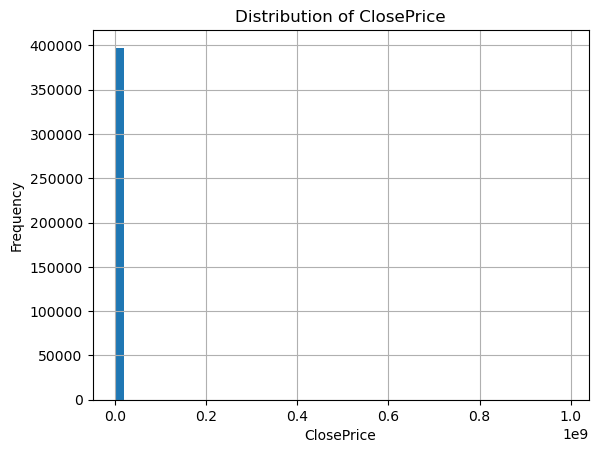

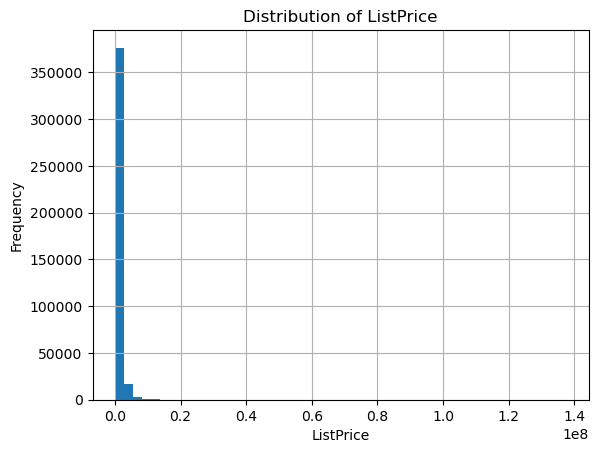

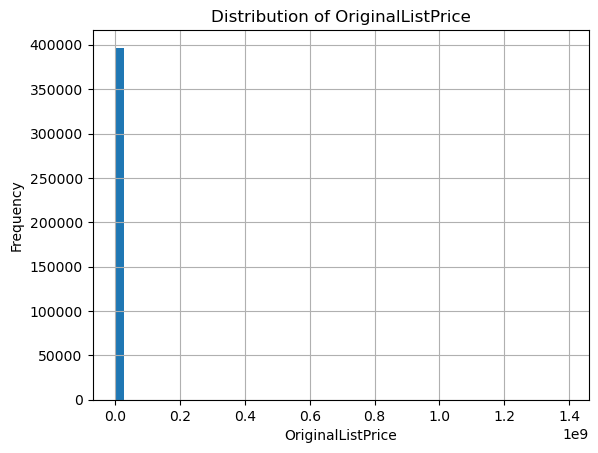

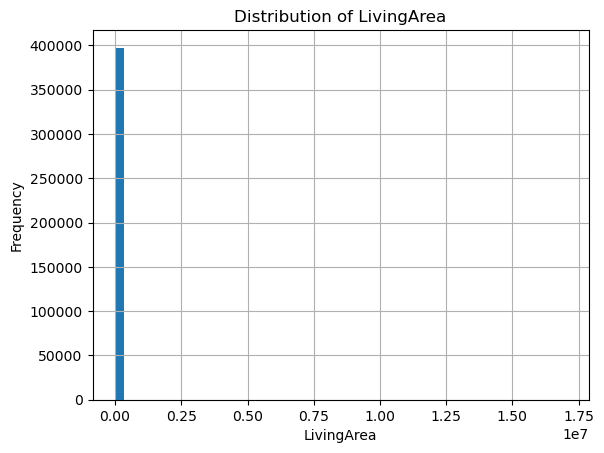

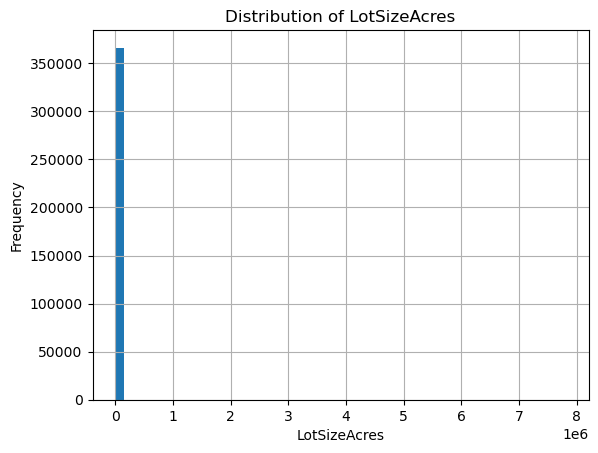

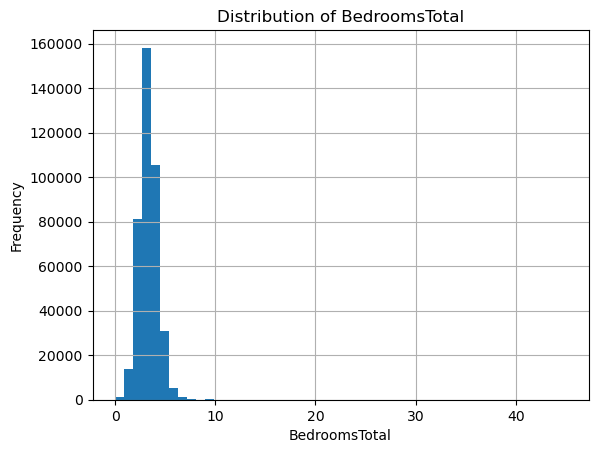

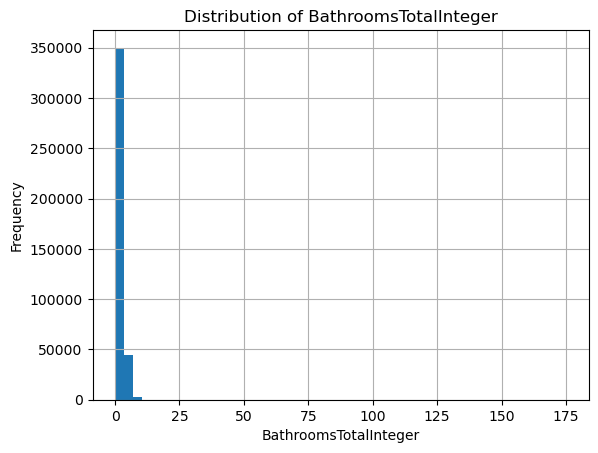

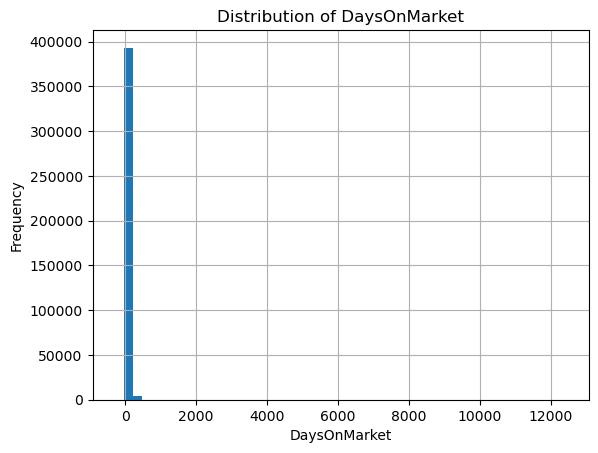

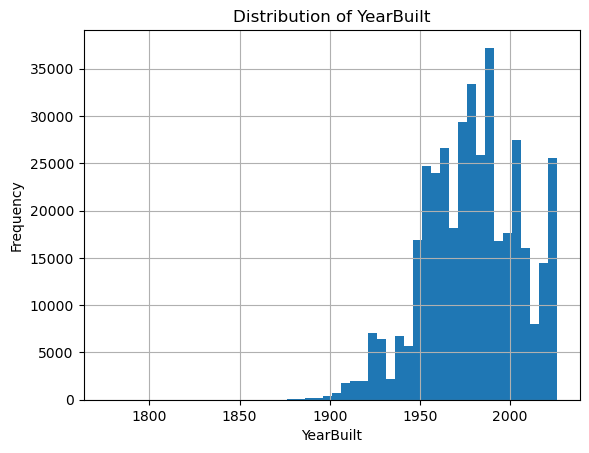

In [31]:
import matplotlib.pyplot as plt

# Loop through each column and plot histogram
for col in numeric_cols:
    plt.figure()
    sold[col].hist(bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

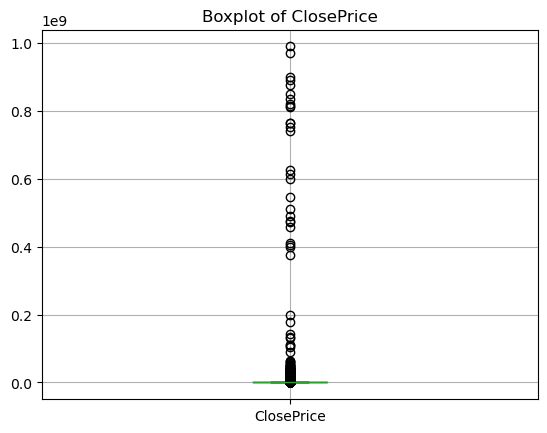

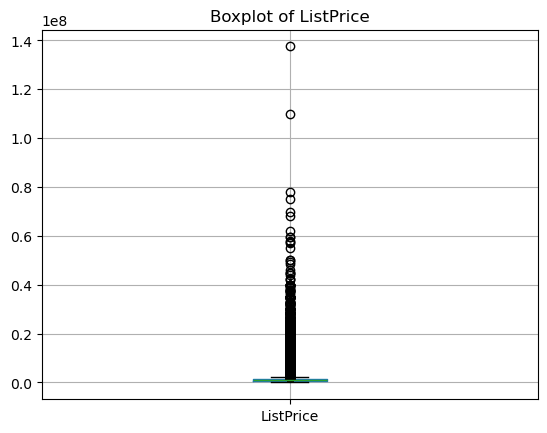

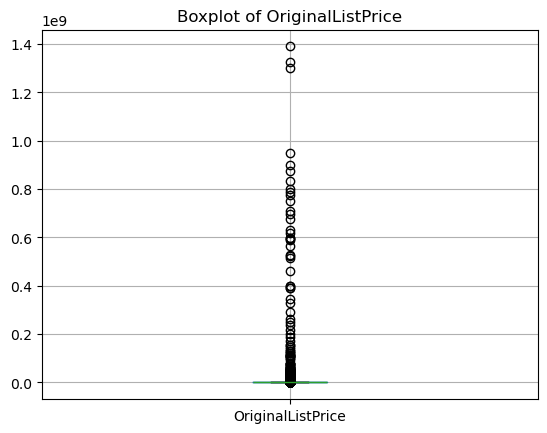

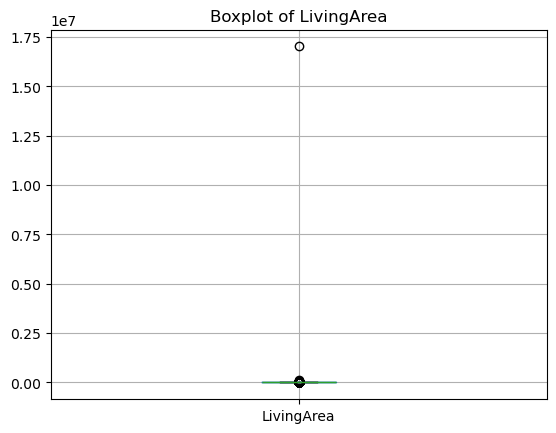

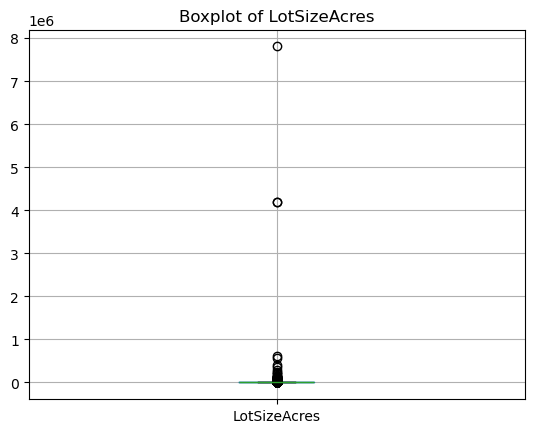

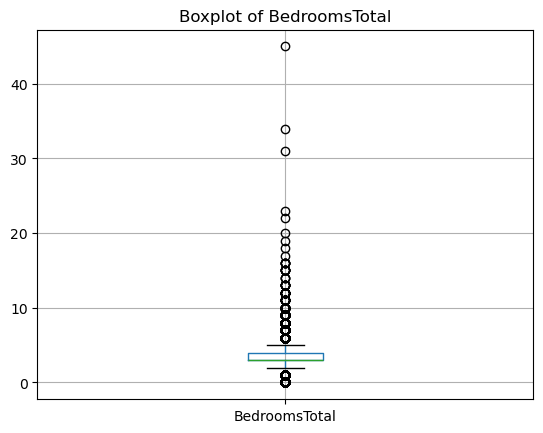

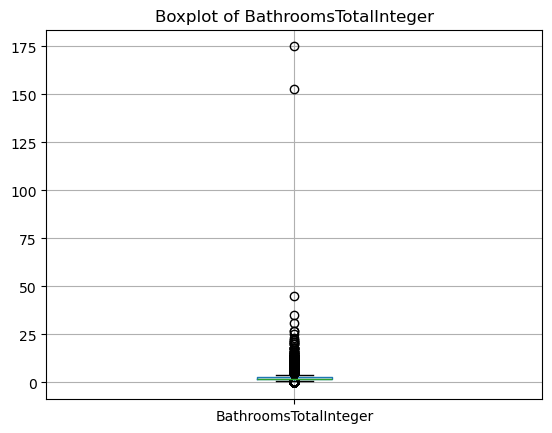

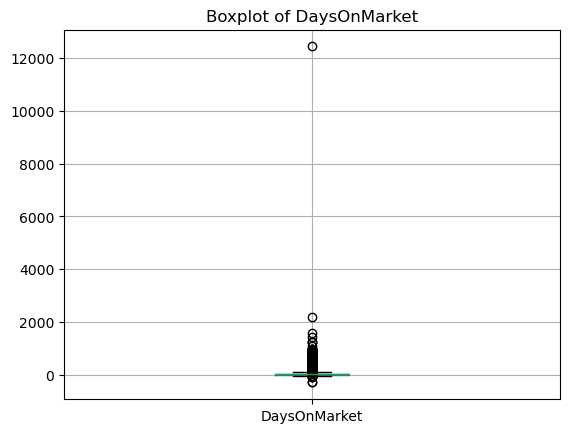

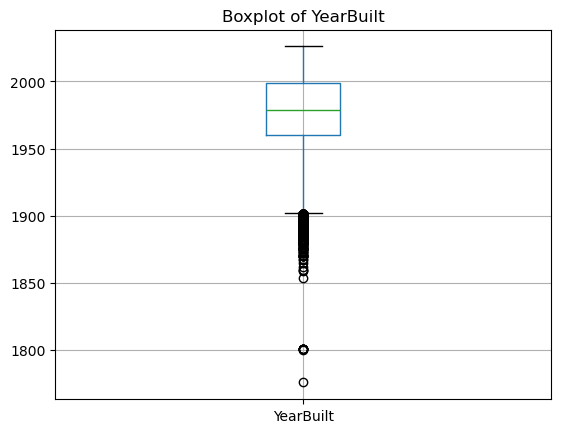

In [32]:
# Boxplots help identify extreme values
for col in numeric_cols:
    plt.figure()
    sold.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

In [33]:
# Example: find suspicious values
for col in numeric_cols:
    print(f"\nColumn: {col}")
    print("Min:", sold[col].min())
    print("Max:", sold[col].max())


Column: ClosePrice
Min: 0.0
Max: 989500000.0

Column: ListPrice
Min: 525.0
Max: 137500000.0

Column: OriginalListPrice
Min: 0.0
Max: 1390000000.0

Column: LivingArea
Min: 0.0
Max: 17021321.0

Column: LotSizeAcres
Min: 0.0
Max: 7810698.3564

Column: BedroomsTotal
Min: 0.0
Max: 45.0

Column: BathroomsTotalInteger
Min: 0.0
Max: 175.0

Column: DaysOnMarket
Min: -288
Max: 12430

Column: YearBuilt
Min: 1776.0
Max: 2026.0


The numeric distribution analysis revealed several data quality issues. Key variables such as ClosePrice, LivingArea, and LotSizeAcres contain invalid values (e.g., zeros) and extreme outliers (e.g., unusually high maximum values). Additionally, fields like YearBuilt include implausible values such as future dates. These observations indicate the need for data cleaning and outlier handling in subsequent steps.

In [34]:
# Count invalid values
print("ClosePrice = 0:", (sold['ClosePrice'] == 0).sum())
print("LivingArea = 0:", (sold['LivingArea'] == 0).sum())
print("DaysOnMarket < 0:", (sold['DaysOnMarket'] < 0).sum())

ClosePrice = 0: 1
LivingArea = 0: 144
DaysOnMarket < 0: 46


In [35]:
# Before cleaning
print("Rows before cleaning:", len(sold))

# Remove invalid values
sold_clean = sold[
    (sold['ClosePrice'] > 0) &
    (sold['LivingArea'] > 0) &
    (sold['DaysOnMarket'] >= 0)
]

# After cleaning
print("Rows after cleaning:", len(sold_clean))

# Check again
print("ClosePrice = 0:", (sold_clean['ClosePrice'] == 0).sum())
print("LivingArea = 0:", (sold_clean['LivingArea'] == 0).sum())
print("DaysOnMarket < 0:", (sold_clean['DaysOnMarket'] < 0).sum())

Rows before cleaning: 397603
Rows after cleaning: 397181
ClosePrice = 0: 0
LivingArea = 0: 0
DaysOnMarket < 0: 0


Removed records with invalid business values such as non-positive ClosePrice, non-positive LivingArea, and negative DaysOnMarket to improve dataset reliability for downstream market analysis.

In [36]:
sold['ClosePrice'].median()

820000.0

In [37]:
sold['ClosePrice'].mean()

1185616.3601253766

### Suggested Intern Questions

What is the Residential vs. other property type share?

In [38]:
# Check distribution of property types
sold['PropertyType'].value_counts(normalize=True) * 100

PropertyType
Residential    100.0
Name: proportion, dtype: float64

What are the median and average close prices?

In [39]:
# Median price
median_price = sold['ClosePrice'].median()

# Mean price
mean_price = sold['ClosePrice'].mean()

print("Median Close Price:", median_price)
print("Average Close Price:", mean_price)

Median Close Price: 820000.0
Average Close Price: 1185616.3601253766


What does the Days on Market distribution look like?

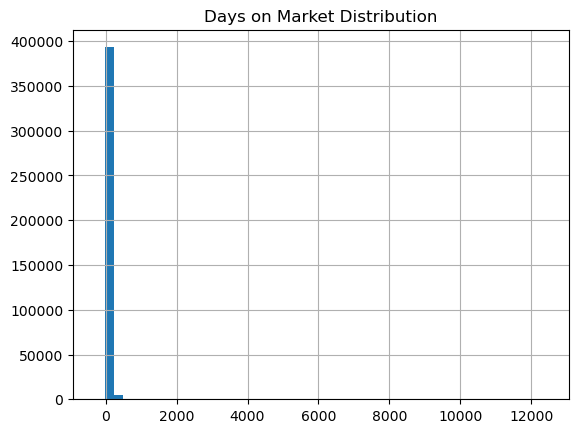

In [40]:
# Summary
sold['DaysOnMarket'].describe()

# Histogram
sold['DaysOnMarket'].hist(bins=50)
plt.title("Days on Market Distribution")
plt.show()

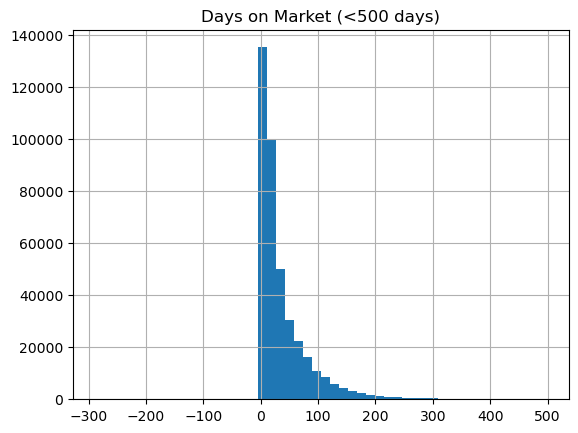

In [41]:
sold[sold['DaysOnMarket'] < 500]['DaysOnMarket'].hist(bins=50)
plt.title("Days on Market (<500 days)")
plt.show()

The Days on Market distribution is right-skewed, with most properties selling within 0–100 days. The histogram shows a strong concentration of values at the lower range, indicating that the majority of homes sell relatively quickly. A gradual decline toward higher values suggests that some properties take longer to sell.

What percentage of homes sold above vs. below list price?

In [42]:
# Above list
above = (sold['ClosePrice'] > sold['ListPrice']).mean() * 100

# Below list
below = (sold['ClosePrice'] < sold['ListPrice']).mean() * 100

print("Above List %:", above)
print("Below List %:", below)

Above List %: 40.11111586180185
Below List %: 42.544447602256525


Note to myself:

Close > List → buyer paid MORE (competitive market)

Close < List → buyer paid LESS (negotiation)

Close = List → exact match

From the above analysis:

40% above list → buyers are competing with each other

42% below list → slightly strong negotiation happening

About 40% of homes sold above the list price, and about 42% sold below it. This means the market is fairly balanced. Slightly more homes are selling below the asking price, which could mean buyers have a bit more negotiating power.

Are there any apparent date consistency issues (e.g., close date before listing date)?

In [43]:
# Convert to datetime
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'])
sold['ListingContractDate'] = pd.to_datetime(sold['ListingContractDate'])

# Check invalid cases
invalid_dates = (sold['CloseDate'] < sold['ListingContractDate']).sum()

print("Invalid date records:", invalid_dates)

Invalid date records: 58


There are 58 records where the CloseDate occurs before the ListingContractDate, which indicates data inconsistencies. These cases are logically invalid since a property cannot be sold before it is listed. These records will need to be addressed during the data cleaning phase.

Which counties have the highest median prices?

In [44]:
# Group by county and compute median price
county_prices = sold.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False)

county_prices.head(10)

CountyOrParish
Del Norte        2485000.0
Other County     2462500.0
San Mateo        1700000.0
Santa Clara      1600000.0
Santa Cruz       1200000.0
San Francisco    1180000.0
Orange           1175000.0
Marin            1170000.0
Alameda          1135000.0
Alpine           1100000.0
Name: ClosePrice, dtype: float64

Counties like San Mateo, Santa Clara, and San Francisco have the highest home prices, which shows that these areas are in high demand. This means sellers can set higher prices, while buyers may find it harder to afford homes. These areas are also good opportunities for investors because property values are high. Overall, this shows that housing markets can vary a lot by location, so strategies should depend on the area.

### Mortgage Rate Enrichment
Enrich both the combined sold and listings datasets by merging in the national 30-year fixed mortgage
rate from the St. Louis Federal Reserve (FRED). This introduces interns to fetching live economic data
from a public API and performing a time-series join on a monthly key.

### Objective
Fetch the FRED MORTGAGE30US series, resample it from weekly to monthly frequency, and merge it
onto both combined datasets using a year-month key derived from transaction dates.

### Background
The FRED MORTGAGE30US series is published weekly (every Thursday) by Freddie Mac via the St.
Louis Federal Reserve. Because MLS transactions are analyzed by calendar month, interns must
resample the weekly data to a monthly average before joining. The data can be fetched directly from
FRED as a CSV—no API key required.

In [45]:
# Fetch mortgage rate data from FRED
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

mortgage = pd.read_csv(url, parse_dates=['observation_date'])


In [46]:
mortgage.columns

Index(['observation_date', 'MORTGAGE30US'], dtype='object')

In [47]:
# Rename columns for clarity
mortgage.columns = ['date', 'rate_30yr_fixed']

In [48]:
# Convert weekly to monthly average
# Create year-month column
mortgage['year_month'] = mortgage['date'].dt.to_period('M')

# Take average rate per month
mortgage_monthly = (
    mortgage.groupby('year_month')['rate_30yr_fixed']
    .mean()
    .reset_index()
)

In [49]:
mortgage_monthly.head()

,year_month,rate_30yr_fixed
0,1971-04,7.3100
1,1971-05,7.4250
2,1971-06,7.5300
3,1971-07,7.6040
4,1971-08,7.6975


In [50]:
# Create year_month in your datasets
# For SOLD -> use CloseDate
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'], errors='coerce')
sold['year_month'] = sold['CloseDate'].dt.to_period('M')

# For LISTINGS -> use ListingContractDate
listings['ListingContractDate'] = pd.to_datetime(listings['ListingContractDate'], errors='coerce')
listings['year_month'] = listings['ListingContractDate'].dt.to_period('M')

In [51]:
# Merge mortgage rates
# Left join so we keep all rows
sold_with_rates = sold.merge(mortgage_monthly, on='year_month', how='left')
listings_with_rates = listings.merge(mortgage_monthly, on='year_month', how='left')

In [52]:
sold_with_rates.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,year_month,rate_30yr_fixed
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,Other,94401,6472.0,NaN,NaN,NaN,NaN,NaN,2024-01,6.6425
1,SanDiego,SanDiego,NaN,False,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN,2024-01,6.6425
2,SanDiego,SanDiego,NaN,False,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN,2024-01,6.6425
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,1079166779,davidmartz@compass.com,2024-01-30,858000.0,...,Palm Springs Unified,92262,NaN,13504.0,NaN,NaN,NaN,NaN,2024-01,6.6425
4,Southland,Southland,NaN,False,False,1890500.0,1075037759,karen.klein@theagencyre.com,2024-01-29,1890500.0,...,Los Angeles Unified,91356,0.0,17873.0,NaN,NaN,NaN,NaN,2024-01,6.6425


In [53]:
listings_with_rates.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1,year_month,rate_30yr_fixed
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,False,NaN,NaN,90067,NaN,2105.00,177861.0,2220 Avenue Of The Stars 2704,2024-01,6.6425
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,16 Palisades,2024-01,6.6425
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,2.0,NaN,91108,NaN,NaN,9404.0,1615 Waverly Road,2024-01,6.6425
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,2250 Indian Creek Road,2024-01,6.6425
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,317 E. Bayfront,2024-01,6.6425


In [54]:
# Validate merge (VERY IMPORTANT)
print("Missing rates in SOLD:", sold_with_rates['rate_30yr_fixed'].isnull().sum())
print("Missing rates in LISTINGS:", listings_with_rates['rate_30yr_fixed'].isnull().sum())

Missing rates in SOLD: 0
Missing rates in LISTINGS: 0


In [55]:
print(sold_with_rates[['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']].head())

   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-01-26    2024-01    240000.0           6.6425
1 2024-01-05    2024-01    815000.0           6.6425
2 2024-01-05    2024-01    810000.0           6.6425
3 2024-01-30    2024-01    858000.0           6.6425
4 2024-01-29    2024-01   1890500.0           6.6425


In [56]:
# Save final enriched datasets
# sold_with_rates.to_csv("RAW/sold_enriched.csv.gz", index=False, compression='gzip')
# listings_with_rates.to_csv("RAW/listings_enriched.csv.gz", index=False, compression='gzip')

# Need to discuss. -> [Errno 28] No space left on device


## Weeks 4–5 – Data Cleaning and Preparation

### Tasks

• Convert date fields to datetime format (CloseDate, PurchaseContractDate, ListingContractDate,
ContractStatusChangeDate)


• Remove unnecessary or redundant columns

• Handle missing values appropriately

• Ensure numeric fields are properly typed

• Remove or flag invalid numeric values: ClosePrice <= 0, LivingArea <= 0, DaysOnMarket < 0,
negative Bedrooms or Bathrooms

### Convert date fields to datetime format

In [57]:
sold_with_rates[['CloseDate', 'PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate']]

,CloseDate,PurchaseContractDate,ListingContractDate,ContractStatusChangeDate
0,2024-01-26,2023-11-22,2021-10-06,2024-01-26
1,2024-01-05,2021-06-30,2021-03-08,2024-01-05
2,2024-01-05,2021-11-18,2021-03-08,2024-01-05
3,2024-01-30,2024-08-05,2024-01-30,2024-01-30
4,2024-01-29,2024-01-29,2024-01-29,2024-01-29
...,...,...,...,...
397598,2026-03-10,2026-01-30,2023-11-16,2026-03-10
397599,2026-03-20,2026-01-12,2023-09-21,2026-03-20
397600,2026-03-30,2026-01-31,2023-05-21,2026-03-30
397601,2026-03-13,2026-02-13,2023-05-19,2026-03-13


In [58]:
listings_with_rates[['CloseDate', 'PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate']]

,CloseDate,PurchaseContractDate,ListingContractDate,ContractStatusChangeDate
0,NaN,2024-05-07,2024-01-01,2024-05-07
1,NaN,NaN,2024-01-24,2024-01-24
2,NaN,NaN,2024-01-12,2024-01-12
3,NaN,NaN,2024-01-20,2024-01-20
4,NaN,NaN,2024-01-12,2024-01-12
...,...,...,...,...
540178,NaN,NaN,2026-03-07,2026-03-07
540179,NaN,NaN,2026-03-24,2026-03-24
540180,NaN,2026-03-20,2026-03-12,2026-03-20
540181,NaN,NaN,2026-03-18,2026-03-18


In [59]:
# SOLD
sold_date_cols = [
    'CloseDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ContractStatusChangeDate'
]
sold_with_rates[sold_date_cols].dtypes

CloseDate                   datetime64[ns]
PurchaseContractDate                object
ListingContractDate         datetime64[ns]
ContractStatusChangeDate            object
dtype: object

In [60]:
# SOLD
sold_date_cols = [
    'CloseDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ContractStatusChangeDate'
]

for col in sold_date_cols:
    if col in sold_with_rates.columns:
        sold_with_rates[col] = pd.to_datetime(sold_with_rates[col], errors='coerce')

In [61]:
sold_with_rates[sold_date_cols].dtypes

CloseDate                   datetime64[ns]
PurchaseContractDate        datetime64[ns]
ListingContractDate         datetime64[ns]
ContractStatusChangeDate    datetime64[ns]
dtype: object

In [62]:
# LISTNGS 
listings_date_cols = [
    'CloseDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ContractStatusChangeDate'
]
listings_with_rates[listings_date_cols].dtypes

CloseDate                           object
PurchaseContractDate                object
ListingContractDate         datetime64[ns]
ContractStatusChangeDate            object
dtype: object

In [63]:
# LISTINGS
listings_date_cols = [
    'CloseDate',
    'PurchaseContractDate',
    'ListingContractDate',
    'ContractStatusChangeDate'
]

for col in listings_date_cols:
    if col in listings_with_rates.columns:
        listings_with_rates[col] = pd.to_datetime(listings_with_rates[col], errors='coerce')

In [64]:
listings_with_rates[listings_date_cols].dtypes

CloseDate                   datetime64[ns]
PurchaseContractDate        datetime64[ns]
ListingContractDate         datetime64[ns]
ContractStatusChangeDate    datetime64[ns]
dtype: object

### Remove unnecessary or redundant columns


In [65]:
print(sold_with_rates.columns)

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince',

In ML: You remove highly correlated features to avoid redundancy

But here in this project: We are doing analysis + insights, not prediction

Therefore Correlation is useful, not something to eliminate

In [66]:
sold_with_rates[['BuyerAgentAOR', 'ListAgentAOR']]

,BuyerAgentAOR,ListAgentAOR
0,Mlslistings,Mlslistings
1,SanDiego,SanDiego
2,SanDiego,SanDiego
3,Mlslistings,Mlslistings
4,Southland,Southland
...,...,...
397598,InlandValleys,InlandValleys
397599,HighDesert,HighDesert
397600,Mrmls,TheInlandGateway
397601,CaliforniaDesert,CaliforniaDesert


In [67]:
(sold_with_rates['BuyerAgentAOR'] == sold_with_rates['ListAgentAOR']).sum()

336248

In [68]:
match_percent = (
    (sold_with_rates['BuyerAgentAOR'] == sold_with_rates['ListAgentAOR'])
    .mean() * 100
)

print(f"Match %: {match_percent:.2f}%")

Match %: 84.57%


In [69]:
sold_with_rates[['LotSizeAcres', 'LotSizeSquareFeet']].head()

# they represent the same information, just in different units.
# LotSizeAcres = acres
# LotSizeSquareFeet = square feet

# 0.3100 acres → 0.3100 × 43560 ≈ 13504 square feet

,LotSizeAcres,LotSizeSquareFeet
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,0.3100,13504.0
4,0.4103,17873.0


In [70]:
# Columns to remove from the dataset
cols_to_drop = [

    # -------- Agent name redundancy --------
    # These columns split agent names into first/last,
    # but we already have full name columns, therefore this is redundant
    'ListAgentFirstName',
    'ListAgentLastName',
    'CoListAgentFirstName',
    'CoListAgentLastName',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',

    # BuyerAgentAOR is highly similar to ListAgentAOR,
    # so it is removed to avoid redundancy
    'BuyerAgentAOR',
    'BuyerAgentMlsId',

    # -------- Address-level details --------
    # Too detailed for this project (we analyze by county/city, not exact address)
    'StreetNumberNumeric',
    'UnparsedAddress',

    # PostalCode is optional; dropped here since analysis is at county level,
    # but can be retained if zip-level analysis is required later
    'PostalCode',   

    
    # -------- Duplicate size information --------
    # Lot size is already available in acres, this one is square feet which is redundant
    'LotSizeSquareFeet',

    # -------- Redundant bedroom information --------
    # MainLevelBedrooms was removed because it provides partial information about bedroom distribution, while BedroomsTotal already captures the total number of bedrooms.
    'MainLevelBedrooms',

    

]

# Drop the selected columns
# errors='ignore' ensures code does not break if any column is missing
sold_with_rates = sold_with_rates.drop(columns=cols_to_drop, errors='ignore')

Column removal was guided by business relevance and analytical usefulness rather than statistical correlation. Since this project focuses on market analysis rather than predictive modeling, variables that are correlated with price (e.g., LivingArea, ListPrice) were retained as they provide meaningful insights into housing trends. Redundant columns were identified based on overlapping information (e.g., lot size in different units), and columns with high missing values or low analytical value were removed.

MainLevelBedrooms was removed because it provides partial information about bedroom distribution, while BedroomsTotal already captures the total number of bedrooms. Since the analysis focuses on overall property characteristics rather than layout-specific details, this column was considered redundant.

In [71]:
sold_with_rates.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'Latitude', 'Longitude', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'AssociationFeeFrequency',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR',
       'YearBuilt', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'MiddleOrJuniorSchool',
       'FireplaceYN', 'Stories', 'HighSchool', 'Levels', 'LotSizeArea',
       'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict',
       'AssociationFee', 'BuyerAgencyCompensationType',
       'BuyerAg

In [72]:
missing_percent_sold_rates = sold_with_rates.isnull().mean() * 100

# show columns with high missing values
print(missing_percent_sold_rates.sort_values(ascending=False).head(25))

BuyerAgencyCompensation        88.399232
BuyerAgencyCompensationType    88.396466
ElementarySchool               86.676157
MiddleOrJuniorSchool           86.587123
lonfilled                      83.932717
latfilled                      83.932717
HighSchool                     82.583129
CoListOfficeName               76.337704
SubdivisionName                62.845351
AssociationFeeFrequency        58.361984
Flooring                       35.862405
HighSchoolDistrict             27.378315
AssociationFee                 22.886648
Stories                        15.468445
AttachedGarageYN               15.261203
MLSAreaMajor                   13.360563
ListAgentAOR                   11.616110
Levels                          9.700380
PoolPrivateYN                   8.660649
ViewYN                          8.518296
LotSizeAcres                    7.888270
LotSizeArea                     7.762265
NewConstructionYN               7.407640
ListAgentEmail                  7.296726
BuyerOfficeAOR  

In [73]:
sold_with_rates[['SubdivisionName']]

,SubdivisionName
0,NaN
1,National City
2,National City
3,NaN
4,NaN
...,...
397598,NaN
397599,NaN
397600,NaN
397601,Not Applicable-1


In [74]:
corr_with_price = sold_with_rates.corr(numeric_only=True)['ClosePrice'] \
    .sort_values(ascending=False)

print(corr_with_price)

ClosePrice                 1.000000
ListPrice                  0.213070
BathroomsTotalInteger      0.110617
BedroomsTotal              0.075051
OriginalListPrice          0.043467
Stories                    0.034359
BuyerAgencyCompensation    0.031699
GarageSpaces               0.011454
AssociationFee             0.006449
DaysOnMarket               0.005631
ListingKey                 0.005078
ListingKeyNumeric          0.005078
LivingArea                 0.004715
LotSizeArea                0.003971
LotSizeAcres               0.000284
YearBuilt                 -0.000211
ParkingTotal              -0.000245
rate_30yr_fixed           -0.000863
Latitude                  -0.002906
Longitude                 -0.011931
Name: ClosePrice, dtype: float64


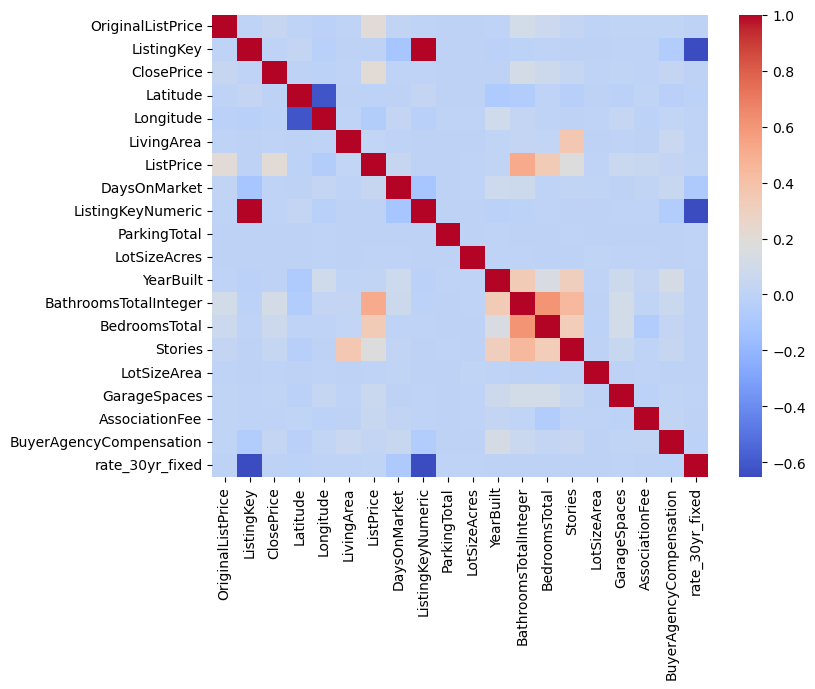

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(sold_with_rates.corr(numeric_only=True), cmap='coolwarm')
plt.show()

In [76]:
additional_drop = [

    # high missing + low value
    'BuyerAgencyCompensation',
    'BuyerAgencyCompensationType',
    'AssociationFeeFrequency',

    # school columns
    'ElementarySchool',
    'MiddleOrJuniorSchool',
    'HighSchool',

    # likely flags 
    'latfilled',
    'lonfilled',

    # too granular
    'SubdivisionName',
 
]

sold_with_rates = sold_with_rates.drop(columns=additional_drop, errors='ignore')

In [77]:
sold_with_rates.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'Latitude', 'Longitude', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'MlsStatus', 'AttachedGarageYN',
       'ParkingTotal', 'PropertySubType', 'LotSizeAcres', 'BuyerOfficeAOR',
       'YearBuilt', 'ListingId', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'AssociationFee', 'year_month',
       'rate_30yr_fixed'],
      dtype='object')

In [78]:
missing_percent_sold_rates = sold_with_rates.isnull().mean() * 100

# show columns with high missing values
print(missing_percent_sold_rates.sort_values(ascending=False).head(25))

CoListOfficeName            76.337704
Flooring                    35.862405
HighSchoolDistrict          27.378315
AssociationFee              22.886648
Stories                     15.468445
AttachedGarageYN            15.261203
MLSAreaMajor                13.360563
ListAgentAOR                11.616110
Levels                       9.700380
PoolPrivateYN                8.660649
ViewYN                       8.518296
LotSizeAcres                 7.888270
LotSizeArea                  7.762265
NewConstructionYN            7.407640
ListAgentEmail               7.296726
BuyerOfficeAOR               5.393822
GarageSpaces                 4.288952
Longitude                    3.979346
Latitude                     3.979346
BuyerOfficeName              1.644354
PropertySubType              0.195170
OriginalListPrice            0.181337
ContractStatusChangeDate     0.148138
ParkingTotal                 0.107142
YearBuilt                    0.089537
dtype: float64


In [79]:
# Additional columns to drop (refined)
additional_drop = [

    # -------- IDs / identifiers (not useful for analysis) --------
    'ListingKey',
    'ListingKeyNumeric',

    # -------- Contact / sensitive info --------
    'ListAgentEmail',
        'ListAgentFirstName',
        'ListAgentLastName',
        'BuyerAgentFirstName',
        'BuyerAgentLastName'

]

# Drop columns safely
sold_with_rates = sold_with_rates.drop(columns=additional_drop, errors='ignore')

In [80]:
sold_with_rates.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'BuyerOfficeAOR', 'YearBuilt', 'ListingId', 'BathroomsTotalInteger',
       'City', 'BedroomsTotal', 'ContractStatusChangeDate',
       'PurchaseContractDate', 'ListingContractDate', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'LotSizeArea', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'AssociationFee', 'year_month',
       'rate_30yr_fixed'],
      dtype='object')

In [81]:
sold_with_rates.shape

(397603, 44)

In [82]:
final_drop = [

    # IDs
    'ListingId',

    # redundant size column, we have LotSizeAcres
    'LotSizeArea',

]

sold_with_rates = sold_with_rates.drop(columns=final_drop, errors='ignore')

In [83]:
sold_with_rates.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'BuyerOfficeAOR', 'YearBuilt', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict',
       'AssociationFee', 'year_month', 'rate_30yr_fixed'],
      dtype='object')

### Remove unnecessary or redundant columns from listings_with_rates

In [84]:
listings_with_rates.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'AssociationFeeFrequency', 'ListingKeyNumeric',
       'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName',
       'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'City', 'BuyerAgencyCompensation',
       'BedroomsTotal', 'ContractStatusChangeDate', 'Lo

In [85]:
missing_percent_listings_rates = listings_with_rates.isnull().mean() * 100

print(missing_percent_listings_rates.sort_values(ascending=False).head(25))

ElementarySchool               88.089592
MiddleOrJuniorSchool           88.062934
BuyerAgencyCompensation        85.376622
BuyerAgencyCompensationType    85.372920
HighSchool                     84.363447
CoListAgentFirstName           77.685340
CoListAgentLastName            77.611106
CoListOfficeName               77.595370
ClosePrice                     73.049874
BuyerOfficeAOR                 72.839760
BuyerOfficeName                70.945032
BuyerOfficeName.1              70.945032
BuyerAgentFirstName            70.661979
BuyerAgentMlsId                70.547574
BuyerAgentLastName             70.527210
CloseDate.1                    69.302625
CloseDate                      69.302625
SubdivisionName                63.172851
AssociationFeeFrequency        57.263187
PurchaseContractDate           50.555275
MainLevelBedrooms              45.554007
HighSchoolDistrict             30.065367
AssociationFee                 24.003347
AttachedGarageYN               17.477966
Stories         

In [86]:
pairs = [
    ('LivingArea', 'LivingArea.1'),
    ('CloseDate', 'CloseDate.1'),
    ('Longitude', 'Longitude.1'),
    ('ListPrice', 'ListPrice.1')
]

for col1, col2 in pairs:
    match = (listings_with_rates[col1].fillna(-1) == listings_with_rates[col2].fillna(-1)).mean()
    print(f"{col1} vs {col2}: {match*100:.2f}% match")

LivingArea vs LivingArea.1: 100.00% match
CloseDate vs CloseDate.1: 69.30% match
Longitude vs Longitude.1: 100.00% match
ListPrice vs ListPrice.1: 100.00% match


In [87]:
# Columns to remove from listings dataset
listings_drop = [

    # -------- IDs (not useful for analysis) --------
    # Just identifiers, not used in analysis
    'ListingKey',
    'ListingKeyNumeric',

    # -------- Contact / name splits --------
    # Email is sensitive and not useful
    # First/Last names are redundant (full name already exists)
    'ListAgentEmail',
    'ListAgentFirstName',
    'ListAgentLastName',
    'CoListAgentFirstName',
    'CoListAgentLastName',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',

    # -------- Buyer-related columns --------
    # Not needed since we are not doing buyer-side analysis
    'BuyerAgentMlsId',
    'BuyerAgencyCompensation',
    'BuyerAgencyCompensationType',
    'BuyerOfficeAOR',
    'BuyerOfficeName',
    'BuyerOfficeName.1',

    # -------- School columns --------
    # Very high missing values and not relevant for this analysis
    'ElementarySchool',
    'MiddleOrJuniorSchool',
    'HighSchool',

    # -------- Duplicate size info --------
    # Same info as LotSizeAcres (just different unit)
    'LotSizeSquareFeet',

    # -------- Redundant bedroom info --------
    # BedroomsTotal already gives total bedrooms
    'MainLevelBedrooms',

    # -------- Address-level details --------
    # Too detailed, not needed for county-level analysis
    'UnparsedAddress',
    'UnparsedAddress.1',
    'StreetNumberNumeric',
    'SubdivisionName',

    # -------- Duplicate columns (.1 versions) --------
    # These are repeated versions of existing columns
    'LivingArea.1',
    'Longitude.1',
    'ListPrice.1',

    # -------- Low-value column --------
    # High missing and not important for analysis
    'AssociationFeeFrequency'
]

# Drop columns safely
# errors='ignore' prevents errors if a column is not present
listings_with_rates = listings_with_rates.drop(columns=listings_drop, errors='ignore')

In [88]:
listings_with_rates.shape

(540183, 45)

In [89]:
sold_with_rates.shape

(397603, 42)

In [90]:
listings_with_rates.columns

Index(['OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'CoListOfficeName', 'ListAgentFullName',
       'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'YearBuilt', 'DaysOnMarket.1',
       'ListingId', 'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'Latitude.1', 'StateOrProvince', 'FireplaceYN',
       'Stories', 'Levels', 'ListAgentLastName.1', 'CloseDate.1',
       'LotSizeArea', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'PostalCode', 'AssociationFee', 'year_month',
       'rate_30yr_fixed'],
      dtype='object')

In [91]:
sold_with_rates.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'BuyerOfficeAOR', 'YearBuilt', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict',
       'AssociationFee', 'year_month', 'rate_30yr_fixed'],
      dtype='object')

In [92]:
# Columns that do NOT match

missing_from_sold = set(listings_with_rates.columns) - set(sold_with_rates.columns)
missing_from_listings = set(sold_with_rates.columns) - set(listings_with_rates.columns)

print("Columns in listings_with_rates but NOT in sold_with_rates:\n")
for col in sorted(missing_from_sold):
    print(col)

print("\n" + "="*60 + "\n")

print("Columns in sold_with_rates but NOT in listings_with_rates:\n")
for col in sorted(missing_from_listings):
    print(col)

Columns in listings_with_rates but NOT in sold_with_rates:

CloseDate.1
DaysOnMarket.1
Latitude.1
ListAgentFirstName.1
ListAgentLastName.1
ListingId
LotSizeArea
PostalCode
PropertyType.1


Columns in sold_with_rates but NOT in listings_with_rates:

BuyerOfficeAOR
BuyerOfficeName
Flooring
ListAgentAOR
PoolPrivateYN
ViewYN


In [93]:
# Drop unwanted columns from listings_with_rates

listings_with_rates = listings_with_rates.drop(
    columns=[
        'Latitude.1',
        'ListAgentFirstName.1',
        'ListAgentLastName.1',
        'ListingId'
    ]
)

# Check updated columns
print(listings_with_rates.columns)
print("\nNew shape:", listings_with_rates.shape)

Index(['OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'CoListOfficeName', 'ListAgentFullName',
       'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'YearBuilt', 'DaysOnMarket.1', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'CloseDate.1', 'LotSizeArea', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'year_month', 'rate_30yr_fixed'],
      dtype='object')

New shape: (540183, 41)


In [94]:
sold_with_rates.shape

(397603, 42)

In [95]:
# Find unmatched columns again

only_in_listings = set(listings_with_rates.columns) - set(sold_with_rates.columns)
only_in_sold = set(sold_with_rates.columns) - set(listings_with_rates.columns)

print("Only in listings_with_rates:")
print(sorted(only_in_listings))

print("\nOnly in sold_with_rates:")
print(sorted(only_in_sold))

Only in listings_with_rates:
['CloseDate.1', 'DaysOnMarket.1', 'LotSizeArea', 'PostalCode', 'PropertyType.1']

Only in sold_with_rates:
['BuyerOfficeAOR', 'BuyerOfficeName', 'Flooring', 'ListAgentAOR', 'PoolPrivateYN', 'ViewYN']


In [96]:
sold_with_rates['ListAgentAOR'].nunique()

59

In [97]:
sold_with_rates[['BuyerOfficeName', 'BuyerOfficeAOR']]

,BuyerOfficeName,BuyerOfficeAOR
0,Bay Area Senior Services,Mlslistings
1,FOSTER HAMILTON Real Estate,SanDiego
2,FOSTER HAMILTON Real Estate,SanDiego
3,NaN,NaN
4,The Agency - Studio City,Glendale
...,...,...
397598,KELLER WILLIAMS RIVERSIDE CENT,InlandValleys
397599,Keller Williams High Desert,HighDesert
397600,NONMEMBER MRML,Mrmls
397601,Non Member Office,PalmSprings


In [98]:
sold_with_rates.columns

Index(['ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'BuyerOfficeAOR', 'YearBuilt', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict',
       'AssociationFee', 'year_month', 'rate_30yr_fixed'],
      dtype='object')

In [99]:
listings_with_rates.columns

Index(['OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'CoListOfficeName', 'ListAgentFullName',
       'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'YearBuilt', 'DaysOnMarket.1', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'CloseDate.1', 'LotSizeArea', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'year_month', 'rate_30yr_fixed'],
      dtype='object')

### Remove or flag invalid numeric values: ClosePrice <= 0, LivingArea <= 0, DaysOnMarket < 0, negative Bedrooms or Bathrooms

#### Remove or flag invalid numeric values from sold_with_rates

In [100]:
# Remove invalid records where ClosePrice is 0 or negative, as these are likely data errors
sold_with_rates = sold_with_rates[
    (sold_with_rates['ClosePrice'] > 0) &
    (sold_with_rates['LivingArea'] > 0) &
    (sold_with_rates['DaysOnMarket'] >= 0) &
    (sold_with_rates['BedroomsTotal'] >= 0) &
    (sold_with_rates['BathroomsTotalInteger'] >= 0)
]

In [101]:
# Flag invalid numeric values in sold_with_rates
sold_with_rates['invalid_flag'] = (
    (sold_with_rates['ClosePrice'] <= 0) |
    (sold_with_rates['LivingArea'] <= 0) |
    (sold_with_rates['DaysOnMarket'] < 0) |
    (sold_with_rates['BedroomsTotal'] < 0) |
    (sold_with_rates['BathroomsTotalInteger'] < 0)
)

sold_with_rates['invalid_flag'].sum()

0

#### Remove or flag invalid numeric values from listings_with_rates

In [102]:
# Remove invalid values from listings_with_rates
listings_with_rates = listings_with_rates[
    (listings_with_rates['ListPrice'] > 0) &
    (listings_with_rates['LivingArea'] > 0) &
    (listings_with_rates['DaysOnMarket'] >= 0) &
    (listings_with_rates['BedroomsTotal'] >= 0) &
    (listings_with_rates['BathroomsTotalInteger'] >= 0)
]

In [103]:
# Flag invalid values
listings_with_rates['invalid_flag'] = (
    (listings_with_rates['ListPrice'] <= 0) |
    (listings_with_rates['LivingArea'] <= 0) |
    (listings_with_rates['DaysOnMarket'] < 0) |
    (listings_with_rates['BedroomsTotal'] < 0) |
    (listings_with_rates['BathroomsTotalInteger'] < 0)
)

In [104]:
listings_with_rates['invalid_flag'].sum()

0

Invalid numeric values were identified and handled by filtering out records with non-positive prices, non-positive living area, negative days on market, and negative bedroom or bathroom counts. Additionally, flag variables were created to track such invalid entries for transparency and validation purposes.

### Handle missing values appropriately

In [105]:
sold_with_rates.head()

,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,CloseDate,ClosePrice,Latitude,Longitude,PropertyType,...,FireplaceYN,Stories,Levels,NewConstructionYN,GarageSpaces,HighSchoolDistrict,AssociationFee,year_month,rate_30yr_fixed,invalid_flag
0,Mlslistings,"Carpet,Tile,Wood",True,False,499000.0,2024-01-26,240000.0,NaN,NaN,Residential,...,True,NaN,NaN,False,1.0,Other,6472.0,2024-01,6.6425,False
1,SanDiego,NaN,False,False,759900.0,2024-01-05,815000.0,NaN,NaN,Residential,...,False,2.0,Two,False,2.0,NaN,NaN,2024-01,6.6425,False
2,SanDiego,NaN,False,False,739900.0,2024-01-05,810000.0,NaN,NaN,Residential,...,False,2.0,Two,False,2.0,NaN,NaN,2024-01,6.6425,False
3,Mlslistings,NaN,False,NaN,NaN,2024-01-30,858000.0,NaN,NaN,Residential,...,False,NaN,NaN,False,2.0,Palm Springs Unified,NaN,2024-01,6.6425,False
4,Southland,NaN,False,False,1890500.0,2024-01-29,1890500.0,34.164376,-118.558749,Residential,...,True,1.0,One,False,2.0,Los Angeles Unified,0.0,2024-01,6.6425,False


In [106]:
# Combine missing values and data types
missing_info = pd.DataFrame({
    'Missing_Count': sold_with_rates.isnull().sum(),
    'Missing_%': sold_with_rates.isnull().mean() * 100,
    'Data_Type': sold_with_rates.dtypes
})

# Sort by missing count
missing_info = missing_info.sort_values(by='Missing_Count', ascending=False)

print(missing_info.head(25))

                          Missing_Count  Missing_%       Data_Type
CoListOfficeName                 303196  76.348134          object
Flooring                         142387  35.854634          object
HighSchoolDistrict               108511  27.324280          object
AssociationFee                    90742  22.849848         float64
Stories                           61404  15.462212         float64
AttachedGarageYN                  60412  15.212415          object
MLSAreaMajor                      53098  13.370669          object
ListAgentAOR                      46117  11.612775          object
Levels                            38530   9.702284          object
PoolPrivateYN                     34323   8.642914          object
ViewYN                            33855   8.525067          object
LotSizeAcres                      31316   7.885718         float64
NewConstructionYN                 29424   7.409291          object
BuyerOfficeAOR                    21420   5.393795          ob

In [107]:
print(missing_info.tail(20))

                       Missing_Count  Missing_%       Data_Type
YearBuilt                        296   0.074536         float64
FireplaceYN                      273   0.068744          object
PurchaseContractDate             194   0.048851  datetime64[ns]
ListAgentFullName                 85   0.021404          object
ListingContractDate                1   0.000252  datetime64[ns]
MlsStatus                          0   0.000000          object
LivingArea                         0   0.000000         float64
rate_30yr_fixed                    0   0.000000         float64
year_month                         0   0.000000       period[M]
CloseDate                          0   0.000000  datetime64[ns]
ClosePrice                         0   0.000000         float64
PropertyType                       0   0.000000          object
StateOrProvince                    0   0.000000          object
ListPrice                          0   0.000000         float64
DaysOnMarket                       0   0

### Treating missing values in sold_with_rates

In [108]:
import pandas as pd
import numpy as np

for column in sold_with_rates.columns:

    # Skip Latitude and Longitude columns
    if column in ['Latitude', 'Longitude']:
        print(f"Skipping {column} (location column)")
        continue

    missing_count = missing_info.loc[column, 'Missing_Count']
    missing_percentage = missing_info.loc[column, 'Missing_%']

    # Skip columns with no missing values
    if missing_count == 0:
        continue

    # Only process columns with < 5% missing
    if missing_percentage >= 5:
        print(f"Skipping {column} ({missing_percentage:.3f}% missing)")
        continue

    column_dtype = sold_with_rates[column].dtype

    print(f"\nProcessing Column: {column}")
    print(f"Missing Values: {missing_count}")
    print(f"Missing %: {missing_percentage:.3f}%")

    # OBJECT COLUMNS
    if column_dtype == 'object':

        if "office" in column.lower() or "agent" in column.lower():
            sold_with_rates[column] = sold_with_rates[column].fillna("Unknown")
            print('Filled object column with "Unknown"')

        else:
            mode_value = sold_with_rates[column].mode()[0]
            sold_with_rates[column] = sold_with_rates[column].fillna(mode_value)
            print(f'Filled object column with mode: {mode_value}')

    # NUMERIC COLUMNS
    elif np.issubdtype(column_dtype, np.number):

        median_value = sold_with_rates[column].median()
        sold_with_rates[column] = sold_with_rates[column].fillna(median_value)
        print(f'Filled numeric column with median: {median_value}')

    # DATETIME COLUMNS
    elif np.issubdtype(column_dtype, np.datetime64):

        sold_with_rates[column] = sold_with_rates[column].fillna(pd.NaT)
        print('Datetime missing values kept as NaT')

Skipping ListAgentAOR (11.613% missing)
Skipping Flooring (35.855% missing)
Skipping ViewYN (8.525% missing)
Skipping PoolPrivateYN (8.643% missing)

Processing Column: OriginalListPrice
Missing Values: 721
Missing %: 0.182%
Filled numeric column with median: 825000.0
Skipping Latitude (location column)
Skipping Longitude (location column)

Processing Column: BuyerOfficeName
Missing Values: 6536
Missing %: 1.646%
Filled object column with "Unknown"
Skipping CoListOfficeName (76.348% missing)

Processing Column: ListAgentFullName
Missing Values: 85
Missing %: 0.021%
Filled object column with "Unknown"
Skipping MLSAreaMajor (13.371% missing)
Skipping AttachedGarageYN (15.212% missing)

Processing Column: ParkingTotal
Missing Values: 426
Missing %: 0.107%
Filled numeric column with median: 2.0

Processing Column: PropertySubType
Missing Values: 774
Missing %: 0.195%
Filled object column with mode: SingleFamilyResidence
Skipping LotSizeAcres (7.886% missing)
Skipping BuyerOfficeAOR (5.394%

C:\Users\tsrap\AppData\Local\Temp\ipykernel_22848\70324508.py:38: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sold_with_rates[column] = sold_with_rates[column].fillna(mode_value)


Treating missing values in listings_with_rates

In [109]:
listings_with_rates.isnull().sum().sort_values(ascending=False)

CoListOfficeName            418464
ClosePrice                  393750
CloseDate                   373510
CloseDate.1                 373510
PurchaseContractDate        272335
HighSchoolDistrict          161504
AssociationFee              129038
Stories                      93979
AttachedGarageYN             93831
Latitude                     80108
Longitude                    80108
MLSAreaMajor                 72940
Levels                       57900
LotSizeAcres                 44431
LotSizeArea                  43597
NewConstructionYN            37113
GarageSpaces                 29461
ContractStatusChangeDate      6012
PropertySubType               1238
OriginalListPrice              774
YearBuilt                      772
City                           562
FireplaceYN                    502
ListAgentFullName               90
StateOrProvince                 48
ParkingTotal                    20
PostalCode                      11
year_month                       0
rate_30yr_fixed     

In [110]:
# Combine missing values and data types
missing_info = pd.DataFrame({
    'Missing_Count': listings_with_rates.isnull().sum(),
    'Missing_%': listings_with_rates.isnull().mean() * 100,
    'Data_Type': listings_with_rates.dtypes
})

# Sort by missing count
missing_info = missing_info.sort_values(by='Missing_Count', ascending=False)

print(missing_info)

                          Missing_Count  Missing_%       Data_Type
CoListOfficeName                 418464  77.615218          object
ClosePrice                       393750  73.031353         float64
CloseDate                        373510  69.277310  datetime64[ns]
CloseDate.1                      373510  69.277310          object
PurchaseContractDate             272335  50.511730  datetime64[ns]
HighSchoolDistrict               161504  29.955189          object
AssociationFee                   129038  23.933510         float64
Stories                           93979  17.430891         float64
AttachedGarageYN                  93831  17.403441          object
Latitude                          80108  14.858148         float64
Longitude                         80108  14.858148         float64
MLSAreaMajor                      72940  13.528652          object
Levels                            57900  10.739087          object
LotSizeAcres                      44431   8.240904         flo

In [111]:
import pandas as pd
import numpy as np

for column in listings_with_rates.columns:
    
    missing_count = missing_info.loc[column, 'Missing_Count']
    missing_percentage = missing_info.loc[column, 'Missing_%']

    # Skip columns with no missing values
    if missing_count == 0:
        continue

    # Only process columns with < 5% missing
    if missing_percentage >= 5:
        print(f"Skipping {column} ({missing_percentage:.3f}% missing)")
        continue

    column_dtype = listings_with_rates[column].dtype

    print(f"\nProcessing Column: {column}")
    print(f"Missing Values: {missing_count}")
    print(f"Missing %: {missing_percentage:.3f}%")

    # OBJECT COLUMNS
    if column_dtype == 'object':

        if "office" in column.lower() or "agent" in column.lower():
            listings_with_rates[column] = listings_with_rates[column].fillna("Unknown")
            print('Filled object column with "Unknown"')

        else:
            mode_value = listings_with_rates[column].mode()[0]
            listings_with_rates[column] = listings_with_rates[column].fillna(mode_value)
            print(f'Filled object column with mode: {mode_value}')

    # NUMERIC COLUMNS
    elif np.issubdtype(column_dtype, np.number):

        median_value = listings_with_rates[column].median()
        listings_with_rates[column] = listings_with_rates[column].fillna(median_value)
        print(f'Filled numeric column with median: {median_value}')

    # DATETIME COLUMNS
    elif np.issubdtype(column_dtype, np.datetime64):

        listings_with_rates[column] = listings_with_rates[column].fillna(pd.NaT)
        print('Datetime missing values kept as NaT')


Processing Column: OriginalListPrice
Missing Values: 774
Missing %: 0.144%
Filled numeric column with median: 849000.0
Skipping CloseDate (69.277% missing)
Skipping ClosePrice (73.031% missing)
Skipping Latitude (14.858% missing)
Skipping Longitude (14.858% missing)
Skipping CoListOfficeName (77.615% missing)

Processing Column: ListAgentFullName
Missing Values: 90
Missing %: 0.017%
Filled object column with "Unknown"
Skipping MLSAreaMajor (13.529% missing)
Skipping AttachedGarageYN (17.403% missing)

Processing Column: ParkingTotal
Missing Values: 20
Missing %: 0.004%
Filled numeric column with median: 2.0

Processing Column: PropertySubType
Missing Values: 1238
Missing %: 0.230%
Filled object column with mode: SingleFamilyResidence
Skipping LotSizeAcres (8.241% missing)

Processing Column: YearBuilt
Missing Values: 772
Missing %: 0.143%
Filled numeric column with median: 1980.0

Processing Column: City
Missing Values: 562
Missing %: 0.104%
Filled object column with mode: Los Angeles

C:\Users\tsrap\AppData\Local\Temp\ipykernel_22848\2299995477.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  listings_with_rates[column] = listings_with_rates[column].fillna(mode_value)


### Week 6 – Feature Engineering and Market Metrics

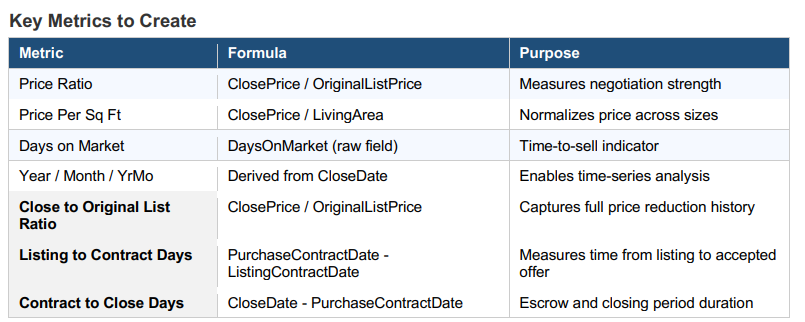

In [119]:
# 1. Price Ratio

"""This compares the final sale price to the original listing price.

Formula:
ClosePrice / OriginalListPrice

Interpretation:
- > 1 → sold above asking
- = 1 → sold at asking
- < 1 → sold below asking"""


invalid_original_price = (
    listings_with_rates['OriginalListPrice'] <= 0
).sum()

print("Invalid OriginalListPrice values:", invalid_original_price)

Invalid OriginalListPrice values: 3


In [120]:
# Step 2 — Create Price Ratio safely
# Avoid division by zero

listings_with_rates['Price_Ratio'] = np.where(
    listings_with_rates['OriginalListPrice'] > 0,

    listings_with_rates['ClosePrice'] /
    listings_with_rates['OriginalListPrice'],

    np.nan
)

In [121]:
# Generate summary statistics for Price_Ratio
print(
    listings_with_rates['Price_Ratio'].describe()
)

count    1.454010e+05
mean     3.789787e+01
std      6.591533e+03
min      6.672227e-04
25%      9.679840e-01
50%      1.000000e+00
75%      1.028623e+00
max      1.800000e+06
Name: Price_Ratio, dtype: float64


In [122]:
# Step 4 — Flag suspicious outliers
# Extreme ratios are likely caused by
# incorrect OriginalListPrice values


listings_with_rates['price_ratio_outlier_flag'] = (
    listings_with_rates['Price_Ratio'] > 5
)

In [123]:
suspicious_ratios = listings_with_rates[
    listings_with_rates['price_ratio_outlier_flag']
][[
    'ClosePrice',
    'OriginalListPrice',
    'Price_Ratio'
]].sort_values(
    by='Price_Ratio',
    ascending=False
)

print(suspicious_ratios.head(20))

         ClosePrice  OriginalListPrice   Price_Ratio
235316    1800000.0               1.00  1.800000e+06
207848    1250000.0               1.25  1.000000e+06
10542     1150000.0               1.20  9.583333e+05
12416      983000.0               1.10  8.936364e+05
371722     600000.0               1.00  6.000000e+05
394359    3860000.0             345.00  1.118841e+04
382177     702500.0              71.50  9.825175e+03
441390    4800000.0             508.00  9.448819e+03
396671     415000.0              45.00  9.222222e+03
388101     895000.0             100.00  8.950000e+03
403508     983000.0             119.00  8.260504e+03
26593      409500.0             130.00  3.150000e+03
2030       685000.0             480.00  1.427083e+03
434732  475000000.0          399999.00  1.187503e+03
9848      1410000.0            1250.00  1.128000e+03
385396    1400000.0            1275.00  1.098039e+03
39108     5725000.0            5495.00  1.041856e+03
465665     910000.0             879.00  1.0352

In [125]:
listings_with_rates = listings_with_rates[
    listings_with_rates['price_ratio_outlier_flag'] == False
]

In [127]:
listings_with_rates['Price_Ratio'].describe()

count    145132.000000
mean          1.007775
std           0.134228
min           0.000667
25%           0.967888
50%           1.000000
75%           1.028511
max           4.946996
Name: Price_Ratio, dtype: float64

The Price_Ratio metric was calculated by dividing ClosePrice by OriginalListPrice. Invalid records with OriginalListPrice less than or equal to zero were handled using NaN to avoid division errors. Extreme ratio values were identified and flagged as outliers after inspection revealed unrealistic OriginalListPrice values such as 1, 45, and 100, which produced inflated ratios. A separate filtered analysis dataset excluding flagged outliers was created for downstream analysis and visualization.


In [128]:
# 2. Price Per Square Foot

"""This normalizes home prices based on size.

Formula:
ClosePrice / LivingArea"""

# Calculate price per square foot
listings_with_rates['Price_Per_SqFt'] = (
    listings_with_rates['ClosePrice'] / listings_with_rates['LivingArea']
)

In [129]:
# Summary statistics
listings_with_rates['Price_Per_SqFt'].describe()

count    145133.000000
mean        631.622682
std         395.932848
min           0.374198
25%         395.332637
50%         563.500534
75%         763.449367
max       60882.800609
Name: Price_Per_SqFt, dtype: float64

In [130]:
# Check infinite values
np.isinf(listings_with_rates['Price_Per_SqFt']).sum()

0

In [131]:
# Count invalid LivingArea values
print((listings_with_rates['LivingArea'] <= 0).sum())

0


The Price_Per_SqFt metric was calculated by dividing ClosePrice by LivingArea to normalize home prices based on property size. Validation checks confirmed that there were no invalid LivingArea values less than or equal to zero and no infinite values generated during calculation. Summary statistics showed a median price per square foot of approximately $564, with most properties falling between $395 and $763 per square foot. A few extreme high-value outliers were observed, indicating potential luxury or anomalous listings that may require further review during outlier analysis.


In [132]:
# 3. Days on Market

"""This tells us how long the property stayed active before selling.

Using the existing raw field."""

# Keep existing market duration field
listings_with_rates['Days_On_Market'] = listings_with_rates['DaysOnMarket']

In [133]:
# Summary statistics
listings_with_rates['Days_On_Market'].describe()

count    538883.000000
mean         19.539928
std          26.761923
min           0.000000
25%           5.000000
50%          11.000000
75%          23.000000
max         731.000000
Name: Days_On_Market, dtype: float64

In [134]:
# Count negative values
print((listings_with_rates['Days_On_Market'] < 0).sum())

0


In [135]:
# Count missing values
print(listings_with_rates['Days_On_Market'].isnull().sum())

0


In [136]:
# View unusually high days on market
listings_with_rates[
    listings_with_rates['Days_On_Market'] > 365
][[
    'ClosePrice',
    'Days_On_Market'
]].sort_values(
    by='Days_On_Market',
    ascending=False
).head(20)

,ClosePrice,Days_On_Market
415758,NaN,731
12941,520000.0,677
178180,NaN,583
411128,NaN,537
195269,NaN,511
439479,NaN,484
85009,NaN,465
520259,NaN,445
190949,NaN,433
195270,NaN,407


In [137]:
# Flag unusually high Days on Market
listings_with_rates['days_on_market_outlier_flag'] = (
    listings_with_rates['Days_On_Market'] > 365
)

In [138]:
listings_with_rates = listings_with_rates[
    listings_with_rates['days_on_market_outlier_flag'] == False
]

In [139]:
# Summary statistics
listings_with_rates['Days_On_Market'].describe()

count    538863.000000
mean         19.523740
std          26.622961
min           0.000000
25%           5.000000
50%          11.000000
75%          23.000000
max         365.000000
Name: Days_On_Market, dtype: float64

The Days_On_Market metric was created using the existing DaysOnMarket field to measure how long properties remained active before selling. Summary statistics showed a median of 11 days and an average of approximately 20 days on market, indicating relatively fast-moving residential listings overall. Properties with exceptionally high market durations were flagged as potential outliers because unusually long listing periods may reflect stale listings, relisted properties, luxury homes, or data inconsistencies. Rather than deleting these records, they were flagged to preserve the integrity of the raw dataset while allowing cleaner downstream analysis.


In [155]:
# 4. Year / Month / Year-Month

# These features help with time-series analysis in Tableau.

# Make sure CloseDate is datetime
listings_with_rates['CloseDate'] = pd.to_datetime(
    listings_with_rates['CloseDate'],
    errors='coerce'
)

# Extract year
listings_with_rates['Year'] = listings_with_rates['CloseDate'].dt.year

# Extract month name
listings_with_rates['Month'] = listings_with_rates['CloseDate'].dt.month_name()

# Create year-month format
listings_with_rates['YrMo'] = listings_with_rates['CloseDate'].dt.to_period('M')

In [156]:
# 5. Close to Original List Ratio: This shows how much the final price changed compared to the original listing.

# Another pricing negotiation metric
listings_with_rates['Close_To_Original_List_Ratio'] = (
    listings_with_rates['ClosePrice'] / listings_with_rates['OriginalListPrice']
)

In [157]:
listings_with_rates[
    'Close_To_Original_List_Ratio'
].describe()

count    1.451300e+05
mean              inf
std               NaN
min      6.672227e-04
25%      9.678849e-01
50%      1.000000e+00
75%      1.028521e+00
max               inf
Name: Close_To_Original_List_Ratio, dtype: float64

In [158]:
np.isinf(
    listings_with_rates[
        'Close_To_Original_List_Ratio'
    ]
).sum()

1

In [159]:
# View rows with infinite values
listings_with_rates[
    np.isinf(
        listings_with_rates[
            'Close_To_Original_List_Ratio'
        ]
    )
][[
    'ClosePrice',
    'OriginalListPrice',
    'Close_To_Original_List_Ratio'
]]

,ClosePrice,OriginalListPrice,Close_To_Original_List_Ratio
415038,267900.0,0.0,inf


In [160]:
# Close to Original List Ratio

listings_with_rates['Close_To_Original_List_Ratio'] = np.where(
    listings_with_rates['OriginalListPrice'] > 0,

    listings_with_rates['ClosePrice'] /
    listings_with_rates['OriginalListPrice'],

    np.nan
)

In [161]:
listings_with_rates[
    'Close_To_Original_List_Ratio'
].describe()

count    145129.000000
mean          1.007774
std           0.134228
min           0.000667
25%           0.967883
50%           1.000000
75%           1.028506
max           4.946996
Name: Close_To_Original_List_Ratio, dtype: float64

In [162]:
np.isinf(
    listings_with_rates[
        'Close_To_Original_List_Ratio'
    ]
).sum()

0

In [163]:
listings_with_rates[
    'close_to_original_list_ratio_outlier_flag'
] = (
    listings_with_rates[
        'Close_To_Original_List_Ratio'
    ] > 5
)

The Close_To_Original_List_Ratio metric was calculated by dividing ClosePrice by OriginalListPrice to measure how much the final sale price changed relative to the original asking price. Summary statistics showed a median ratio of 1.00 and an average of approximately 1.008, indicating that most homes sold very close to their original listing price. Most properties fell between 0.968 and 1.029, while a small number of higher ratios were identified as potential outliers for further review.


In [164]:
# 6. Listing to Contract Days: Measures how many days it took to receive an accepted offer.

# Formula: PurchaseContractDate - ListingContractDate

# Convert date columns
listings_with_rates['PurchaseContractDate'] = pd.to_datetime(
    listings_with_rates['PurchaseContractDate'],
    errors='coerce'
)

listings_with_rates['ListingContractDate'] = pd.to_datetime(
    listings_with_rates['ListingContractDate'],
    errors='coerce'
)

# Calculate time to contract
listings_with_rates['Listing_To_Contract_Days'] = (
    listings_with_rates['PurchaseContractDate'] -
    listings_with_rates['ListingContractDate']
).dt.days

In [165]:
# Count missing values
print(
    listings_with_rates[
        'Listing_To_Contract_Days'
    ].isnull().sum()
)

272320


In [166]:
# Summary statistics
listings_with_rates['Listing_To_Contract_Days'].describe()

count    266543.000000
mean         23.421673
std          28.632146
min        -731.000000
25%           7.000000
50%          13.000000
75%          27.000000
max         258.000000
Name: Listing_To_Contract_Days, dtype: float64

In [167]:
# Flag invalid negative timelines
listings_with_rates['negative_timeline_flag'] = (
    listings_with_rates['Listing_To_Contract_Days'] < 0
)

In [168]:
listings_with_rates[
    listings_with_rates['negative_timeline_flag']
][[
    'ListingContractDate',
    'PurchaseContractDate',
    'Listing_To_Contract_Days'
]].head(20)

,ListingContractDate,PurchaseContractDate,Listing_To_Contract_Days
1406,2024-01-31,2024-01-15,-16.0
1712,2024-01-18,2024-01-05,-13.0
2665,2024-01-29,2024-01-08,-21.0
4140,2024-01-26,2024-01-10,-16.0
12206,2024-01-11,2024-01-09,-2.0
13704,2024-01-09,2024-01-07,-2.0
16407,2024-01-02,2023-12-04,-29.0
16980,2024-01-22,2024-01-04,-18.0
22123,2024-02-23,2024-02-14,-9.0
22181,2024-02-16,2024-01-27,-20.0


In [170]:
listing_contract_analysis = listings_with_rates[
    listings_with_rates['negative_timeline_flag'] == False
]

listing_contract_analysis[
    'Listing_To_Contract_Days'
].describe()

count    266275.000000
mean         23.466108
std          28.568373
min           0.000000
25%           7.000000
50%          13.000000
75%          27.000000
max         258.000000
Name: Listing_To_Contract_Days, dtype: float64

In [171]:
# 7. Contract to Close Days: Measures the escrow/closing duration.

# Formula: CloseDate - PurchaseContractDate

# Convert date columns
listings_with_rates['CloseDate'] = pd.to_datetime(
    listings_with_rates['CloseDate'], 
    errors='coerce'
)
listings_with_rates['PurchaseContractDate'] = pd.to_datetime(
    listings_with_rates['PurchaseContractDate'],
    errors='coerce'
)
# Calculate contract to close duration
listings_with_rates['Contract_To_Close_Days'] = (
    listings_with_rates['CloseDate'] -
    listings_with_rates['PurchaseContractDate']
).dt.days

In [172]:
# Summary statistics
listings_with_rates['Contract_To_Close_Days'].describe()

count    165337.000000
mean         26.809069
std          17.480970
min        -169.000000
25%          18.000000
50%          25.000000
75%          32.000000
max        1484.000000
Name: Contract_To_Close_Days, dtype: float64

In [173]:
# Count missing values
print(
    listings_with_rates[
        'Contract_To_Close_Days'
    ].isnull().sum()
)

373526


In [174]:
# Count negative values
print(
    (
        listings_with_rates[
            'Contract_To_Close_Days'
        ] < 0
    ).sum()
)

248


In [175]:
# View invalid negative durations
listings_with_rates[
    listings_with_rates[
        'Contract_To_Close_Days'
    ] < 0
][[
    'PurchaseContractDate',
    'CloseDate',
    'Contract_To_Close_Days'
]].head(20)

,PurchaseContractDate,CloseDate,Contract_To_Close_Days
309,2024-03-04,2024-01-31,-33.0
919,2024-02-05,2024-01-31,-5.0
974,2024-02-04,2024-01-29,-6.0
1271,2024-02-01,2024-01-29,-3.0
4136,2024-01-26,2024-01-25,-1.0
6947,2024-01-21,2024-01-10,-11.0
7497,2024-01-19,2024-01-16,-3.0
8587,2024-01-18,2024-01-16,-2.0
10945,2024-01-14,2024-01-13,-1.0
15348,2024-04-26,2024-04-24,-2.0


In [176]:
# Flag invalid negative contract-to-close durations
listings_with_rates['negative_contract_close_flag'] = (
    listings_with_rates['Contract_To_Close_Days'] < 0
)

# Create analysis-ready dataset without negative values
contract_close_analysis = listings_with_rates[
    listings_with_rates['negative_contract_close_flag'] == False
]

# Summary statistics without negative values
contract_close_analysis[
    'Contract_To_Close_Days'
].describe()

count    165089.000000
mean         26.860542
std          17.435808
min           0.000000
25%          18.000000
50%          25.000000
75%          32.000000
max        1484.000000
Name: Contract_To_Close_Days, dtype: float64

The Contract_To_Close_Days metric was calculated by subtracting PurchaseContractDate from CloseDate to measure the escrow and closing duration for each transaction. After excluding records with invalid negative durations, the cleaned analysis dataset showed a median closing period of 25 days and an average of approximately 27 days, indicating that most residential transactions closed within about one month. Negative values were flagged as timeline inconsistencies because a property cannot close before the contract is signed. These records were preserved in the raw dataset through flag columns while being excluded from the analysis-ready dataset used for downstream reporting and visualization.


In [177]:
listings_with_rates.columns

Index(['OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'CoListOfficeName', 'ListAgentFullName',
       'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'YearBuilt', 'DaysOnMarket.1', 'BathroomsTotalInteger', 'City',
       'BedroomsTotal', 'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'CloseDate.1', 'LotSizeArea', 'NewConstructionYN',
       'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'year_month', 'rate_30yr_fixed', 'invalid_flag', 'Price_Ratio',
       'price_ratio_outlier_flag', 'Price_Per_SqFt', 'Days_On_Market',
       'days_on_market_outlier_flag', 'Year', 'Month', 'YrMo',
       'Close_To_Original_List_Ratio',
       'close_to_original_l

### Segment Analysis

Now that the market metrics are created, we group the data by important business dimensions to identify patterns.

This helps answer questions like:
- Which property types sell faster?
- Which counties have higher price per square foot?
- Which offices close deals faster?

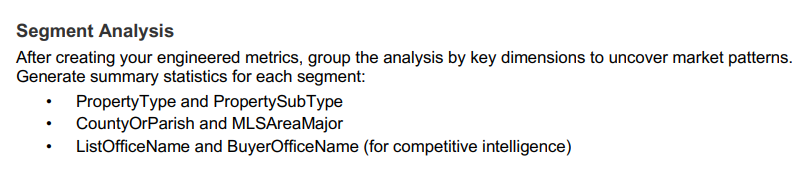

In [178]:
# 1. Property Type Analysis

"""Group by:
- PropertyType
- PropertySubType

This helps compare different kinds of homes."""

# Summary statistics by property category
property_analysis = listings_with_rates.groupby(
    ['PropertyType', 'PropertySubType']
)[
    [
        'ClosePrice',
        'Price_Per_SqFt',
        'Days_On_Market',
        'Price_Ratio',
        'Listing_To_Contract_Days',
        'Contract_To_Close_Days'
    ]
].agg(['mean', 'median', 'count'])

property_analysis.head()

ClosePrice                  Price_Per_SqFt  \
                                      mean    median  count           mean   
PropertyType PropertySubType                                                 
Residential  Apartment                 NaN       NaN      0            NaN   
             BoatSlip         2.347864e+05  182000.0     22    2055.250000   
             Cabin            2.696938e+05  248000.0    125     322.976015   
             CoOwnership      1.829500e+06  844000.0      4     827.035179   
             Condominium      7.748870e+05  635000.0  23655     614.279117   

                                                 Days_On_Market                \
                                   median  count           mean median  count   
PropertyType PropertySubType                                                    
Residential  Apartment                NaN      0      23.000000   23.0      1   
             BoatSlip         1675.000000     22      20.802817    4.0     71   
             Cabin             277.777778    125      23.878151    8.0    952   
             CoOwnership       652.369138      4       9.231884    4.0     69   
             Condominium       574.866310  23655      21.571516   13.0  97607   

                             Price_Ratio                   \
                                    mean    median  count   
PropertyType PropertySubType                                
Residential  Apartment               NaN       NaN      0   
             BoatSlip           0.955305  0.969300     22   
             Cabin              0.900549  0.936508    125   
             CoOwnership        1.265876  1.005562      4   
             Condominium        0.988116  0.996364  23655   

                             Listing_To_Contract_Days                \
                                                 mean median  count   
PropertyType PropertySubType                                          
Residential  Apartment                            NaN    NaN      0   
             BoatSlip                       23.814815   12.0     27   
             Cabin                          37.352941   19.5    238   
             CoOwnership                    28.900000   19.0     10   
             Condominium                    26.195482   15.0  42014   

                             Contract_To_Close_Days                
                                               mean median  count  
PropertyType PropertySubType                                       
Residential  Apartment                          NaN    NaN      0  
             BoatSlip                     16.045455   14.0     22  
             Cabin                        28.432000   26.0    125  
             CoOwnership                  37.750000   35.5      4  
             Condominium                  26.252232   25.0  26095

Interpreation: 

In [179]:
# 2. County / Market Area Analysis

"""Group by:
- CountyOrParish
- MLSAreaMajor

This helps identify strong and weak markets geographically."""

# Geographic market comparison
location_analysis = listings_with_rates.groupby(
    ['CountyOrParish', 'MLSAreaMajor']
)[
    [
        'ClosePrice',
        'Price_Per_SqFt',
        'Days_On_Market',
        'Price_Ratio'
    ]
].agg(['mean', 'median', 'count'])

location_analysis.head()

ClosePrice                   \
                                          mean     median count   
CountyOrParish MLSAreaMajor                                       
Alameda        699 - Not Defined  1.328096e+06  1230000.0   640   
               BERK - Berkeley    4.664995e+05   466499.5     2   
               GLV - Glenview              NaN        NaN     0   
               VTU - Ventura               NaN        NaN     0   
Alpine         699 - Not Defined           NaN        NaN     0   

                                 Price_Per_SqFt                    \
                                           mean      median count   
CountyOrParish MLSAreaMajor                                         
Alameda        699 - Not Defined     806.464666  752.917242   640   
               BERK - Berkeley       560.519401  560.519401     2   
               GLV - Glenview               NaN         NaN     0   
               VTU - Ventura                NaN         NaN     0   
Alpine         699 - Not Defined            NaN         NaN     0   

                                 Days_On_Market              Price_Ratio  \
                                           mean median count        mean   
CountyOrParish MLSAreaMajor                                                
Alameda        699 - Not Defined      18.226084   12.0  3021    1.068827   
               BERK - Berkeley        29.200000   38.0     5    1.152499   
               GLV - Glenview         20.000000   20.0     1         NaN   
               VTU - Ventura          18.000000   18.0     2         NaN   
Alpine         699 - Not Defined       0.000000    0.0     1         NaN   

                                                  
                                    median count  
CountyOrParish MLSAreaMajor                       
Alameda        699 - Not Defined  1.035203   640  
               BERK - Berkeley    1.152499     2  
               GLV - Glenview          NaN     0  
               VTU - Ventura           NaN     0  
Alpine         699 - Not Defined       NaN     0

In [180]:
# 3. Listing Office Performance

"""Group by:
- ListOfficeName

This helps compare seller-side office performance."""

# Listing office performance metrics
listing_office_analysis = listings_with_rates.groupby(
    'ListOfficeName'
)[
    [
        'ClosePrice',
        'Days_On_Market',
        'Price_Ratio',
        'Listing_To_Contract_Days'
    ]
].agg(['mean', 'median', 'count'])

listing_office_analysis.sort_values(
    ('ClosePrice', 'count'),
    ascending=False
).head(10)

ClosePrice             \
                                                            mean     median   
ListOfficeName                                                                
Compass                                             1.792105e+06  1350000.0   
Coldwell Banker Realty                              1.557703e+06  1208000.0   
Keller Williams Realty                              1.044775e+06   885000.0   
First Team Real Estate                              1.118090e+06   960000.0   
Real Broker                                         1.071203e+06   867000.0   
Intero Real Estate Services                         1.682356e+06  1440000.0   
Berkshire Hathaway HomeServices California Prop...  1.567773e+06  1010000.0   
eXp Realty of California Inc                        9.904939e+05   800000.0   
eXp Realty of California, Inc.                      9.596133e+05   780000.0   
Equity Union                                        1.101537e+06   890000.0   

                                                          Days_On_Market  \
                                                    count           mean   
ListOfficeName                                                             
Compass                                             11913      18.169701   
Coldwell Banker Realty                               7066      19.682250   
Keller Williams Realty                               2946      17.298688   
First Team Real Estate                               1913      17.524151   
Real Broker                                          1803      17.677927   
Intero Real Estate Services                          1791      16.629624   
Berkshire Hathaway HomeServices California Prop...   1768      20.778558   
eXp Realty of California Inc                         1673      20.306921   
eXp Realty of California, Inc.                       1318      15.707274   
Equity Union                                         1242      24.140698   

                                                                 Price_Ratio  \
                                                   median  count        mean   
ListOfficeName                                                                 
Compass                                              11.0  38279    1.036319   
Coldwell Banker Realty                               11.0  23764    1.024492   
Keller Williams Realty                               10.0   9448    1.012316   
First Team Real Estate                               10.0   6004    1.001412   
Real Broker                                          10.0   6039    1.003130   
Intero Real Estate Services                          10.0   6164    1.078181   
Berkshire Hathaway HomeServices California Prop...   12.0   7117    0.991805   
eXp Realty of California Inc                         12.0   5982    1.007875   
eXp Realty of California, Inc.                        9.0   4564    1.006917   
Equity Union                                         15.0   5160    0.984383   

                                                                     \
                                                      median  count   
ListOfficeName                                                        
Compass                                             1.000000  11913   
Coldwell Banker Realty                              1.000000   7066   
Keller Williams Realty                              1.000000   2946   
First Team Real Estate                              1.000000   1913   
Real Broker                                         1.000000   1803   
Intero Real Estate Services                         1.035058   1791   
Berkshire Hathaway HomeServices California Prop...  0.994827   1768   
eXp Realty of California Inc                        1.000000   1673   
eXp Realty of California, Inc.                      1.000103   1318   
Equity Union                                        0.988434   1242   

                                                   Listing_To_Contract_D

#### 1. Which Property Types Sell Faster?

We compare the average number of days a property stays on the market.

Lower Days_On_Market = faster sales

In [181]:
# Average days on market by property type
fastest_property_types = listings_with_rates.groupby(
    'PropertyType'
)['Days_On_Market'].mean().sort_values()

fastest_property_types

PropertyType
Residential    19.52374
Name: Days_On_Market, dtype: float64

In [182]:
# Convert to cleaner dataframe
fastest_property_types_df = fastest_property_types.reset_index()
fastest_property_types_df.columns = ['PropertyType', 'Avg_Days_On_Market']

fastest_property_types_df

,PropertyType,Avg_Days_On_Market
0,Residential,19.52374


In [183]:
# 2. Which Counties Have Higher Price Per Square Foot?
county_price_analysis = listings_with_rates.groupby(
    'CountyOrParish'
)['Price_Per_SqFt'].mean().sort_values(ascending=False)

county_price_analysis


CountyOrParish
San Mateo          1147.034452
Santa Clara        1110.460508
San Francisco       963.290355
Santa Cruz          850.078457
Marin               849.595969
                      ...     
Modoc               138.310894
Alpine                     NaN
Del Norte                  NaN
Foreign Country            NaN
Humboldt                   NaN
Name: Price_Per_SqFt, Length: 63, dtype: float64

In [184]:
county_price_analysis_df = county_price_analysis.reset_index()
county_price_analysis_df.columns = ['CountyOrParish', 'Avg_Price_Per_SqFt']

county_price_analysis_df.head(15)

,CountyOrParish,Avg_Price_Per_SqFt
0,San Mateo,1147.034452
1,Santa Clara,1110.460508
2,San Francisco,963.290355
3,Santa Cruz,850.078457
4,Marin,849.595969
5,Orange,755.940910
6,Alameda,751.623857
7,Monterey,742.749048
8,Mono,713.751777
9,Los Angeles,690.220242


In [185]:
# 3. Which Offices Close Deals Faster?

office_closing_speed = listings_with_rates.groupby(
    'ListOfficeName'
)['Contract_To_Close_Days'].mean().sort_values()

office_closing_speed    

ListOfficeName
Kandell Properties Group, Inc.       -10.0
Synergy3                              -6.0
GenX Realty, Inc.                     -3.0
New Directions Real Estate Service    -2.0
Gold House Realty & Mortgage          -1.0
                                      ... 
illi Commercial Real Estate            NaN
inmobi properties                      NaN
simpliHOM Inc                          NaN
socalhomeshop Inc.                     NaN
uDream Real Estate                     NaN
Name: Contract_To_Close_Days, Length: 20666, dtype: float64

In [188]:
# Count transactions per office
office_volume = contract_close_analysis.groupby(
    'ListOfficeName'
).size()

# Keep offices with meaningful transaction volume
valid_offices = office_volume[
    office_volume >= 20
].index

# Average contract-to-close duration
office_closing_speed_filtered = (
    contract_close_analysis[
        contract_close_analysis[
            'ListOfficeName'
        ].isin(valid_offices)
    ]
    .groupby('ListOfficeName')[
        'Contract_To_Close_Days'
    ]
    .mean()
    .sort_values()
)

office_closing_speed_filtered.head(15)

ListOfficeName
Holly's Homes Desert Princess                       0.000000
Engel & Voelkers San Francisco, Mendocino Branch    0.000000
Plus Real Estate Group                              1.500000
BPO Homes                                           1.916667
Robin Oates Real Estate Inc                         2.250000
Pacific Property Services Co.                       2.400000
CBC Sales Corporation                               2.500000
Mountain View Premier Realty                        3.600000
Thunderbird Realty                                  3.600000
Riviera West Realtors, Inc.                         3.705882
BD Homes - Eldorado Properties                      3.866667
Keller Williams Porter Ranch                        4.000000
Westside Estate Agency-Malibu                       4.000000
Lux Box Agency                                      4.000000
Sharon Rose Realty, Inc.                            4.055556
Name: Contract_To_Close_Days, dtype: float64

In [189]:
# Top Performing Counties
top_counties = listings_with_rates.groupby(
    'CountyOrParish'
)['ClosePrice'].mean().sort_values(ascending=False)

top_counties.head(10)

# other columns (close price is okay, but I have to look for other columns that are not already analyzed)

CountyOrParish
San Mateo        2.199752e+06
Santa Clara      1.954594e+06
Marin            1.550212e+06
Orange           1.476047e+06
Santa Barbara    1.367767e+06
Santa Cruz       1.364072e+06
San Francisco    1.361870e+06
Monterey         1.325336e+06
Alameda          1.312457e+06
Los Angeles      1.293951e+06
Name: ClosePrice, dtype: float64

### Week 7 – Outlier Detection and Data Quality

In [190]:
# Numeric columns to check for outliers
outlier_columns = [
    'ClosePrice',
    'LivingArea',
    'Days_On_Market',
    'Price_Per_SqFt'
]

In [191]:
# Create a working copy: This protects the original cleaned dataset in case we need it later.
flagged_listings = listings_with_rates.copy()

#### Apply IQR Method

For each column:
1. Find Q1 (25th percentile)
2. Find Q3 (75th percentile)
3. Calculate IQR
4. Define lower and upper bounds
5. Create a flag column [Do not Delete]

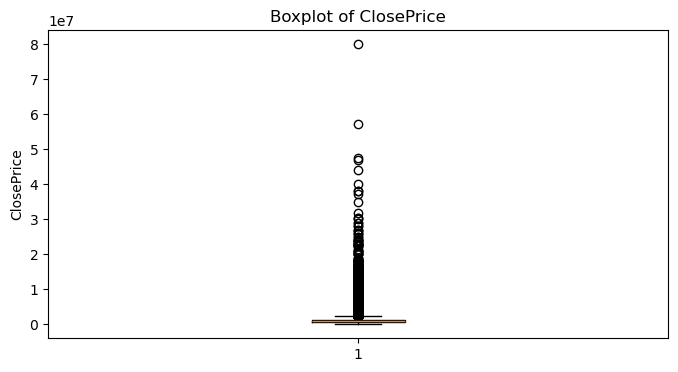

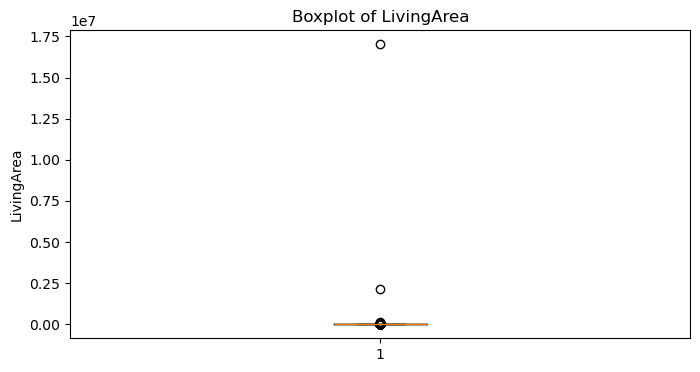

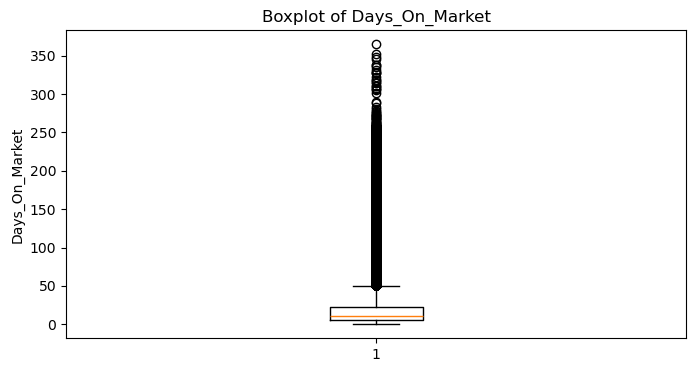

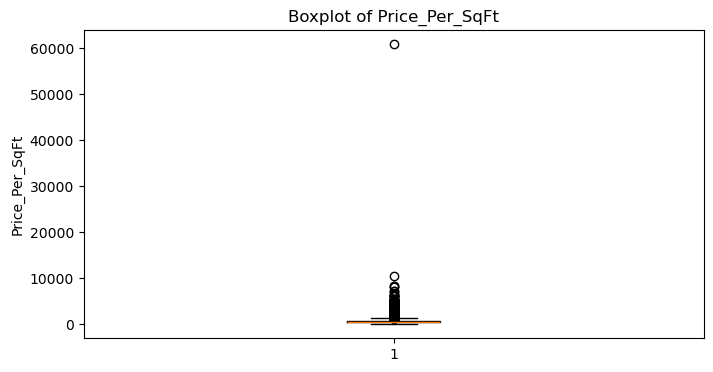

In [192]:
import matplotlib.pyplot as plt

# Create boxplots
for column in outlier_columns:
    
    plt.figure(figsize=(8, 4))
    
    # Boxplot for current column
    plt.boxplot(listings_with_rates[column].dropna())
    
    plt.title(f'Boxplot of {column}')
    plt.ylabel(column)
    
    plt.show()

In [ ]:
for column in outlier_columns:
    
    print(f"\nProcessing {column}")

    # Quartiles
    Q1 = flagged_listings[column].quantile(0.25)
    Q3 = flagged_listings[column].quantile(0.75)

    # Interquartile range
    IQR = Q3 - Q1

    # Bounds
    # lower_bound = Q1 - (1.5 * IQR)

    # For some columns like price, we know that negative values are impossible, so we can set the lower bound to 0 instead of a negative number.
    lower_bound = max(0, Q1 - (1.5 * IQR))
    upper_bound = Q3 + (1.5 * IQR)

    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)

    # Create outlier flag
    flagged_listings[f'{column}_Outlier'] = (
        (flagged_listings[column] < lower_bound) |
        (flagged_listings[column] > upper_bound)
    )

    print(
        "Outliers found:",
        flagged_listings[f'{column}_Outlier'].sum()
    )


Processing ClosePrice
Lower Bound: 0
Upper Bound: 2475000.0
Outliers found: 10310

Processing LivingArea
Lower Bound: 0
Upper Bound: 3878.0
Outliers found: 26702

Processing Days_On_Market
Lower Bound: 0
Upper Bound: 50.0
Outliers found: 45007

Processing Price_Per_SqFt
Lower Bound: 0
Upper Bound: 1315.6489790911214
Outliers found: 6487


In [201]:
clean_filtered_listings = flagged_listings[
    ~(
        flagged_listings['ClosePrice_Outlier'] |
        flagged_listings['LivingArea_Outlier'] |
        flagged_listings['Days_On_Market_Outlier'] |
        flagged_listings['Price_Per_SqFt_Outlier']
    )
].copy()

In [202]:
print("Original dataset shape:", listings_with_rates.shape)
print("Filtered dataset shape:", flagged_listings.shape)

Original dataset shape: (538863, 56)
Filtered dataset shape: (538863, 60)


In [203]:
comparison_size = pd.DataFrame({
    'Dataset': ['Original Full Dataset', 'Clean Filtered Dataset'],
    'Rows': [
        len(flagged_listings),
        len(clean_filtered_listings)
    ]
})

comparison_size

,Dataset,Rows
0,Original Full Dataset,538863
1,Clean Filtered Dataset,461295


In [211]:
median_comparison = pd.DataFrame({
    'Original_Median': flagged_listings[outlier_columns].median(),
    'Filtered_Median': clean_filtered_listings[outlier_columns].median()
})

median_comparison

,Original_Median,Filtered_Median
ClosePrice,854000.000000,817000.0
LivingArea,1669.000000,1614.0
Days_On_Market,11.000000,10.0
Price_Per_SqFt,563.507669,550.0


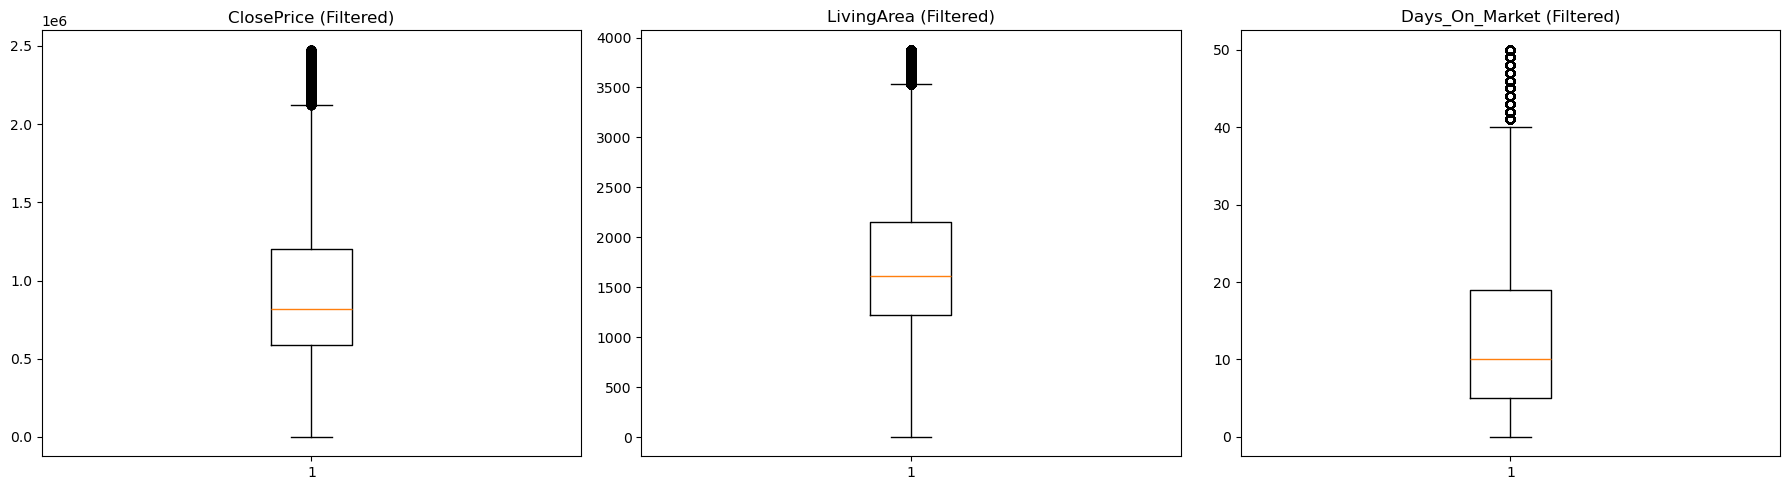

In [212]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column in zip(axes, outlier_columns):
    
    ax.boxplot(clean_filtered_listings[column].dropna())
    ax.set_title(f'{column} (Filtered)')

plt.tight_layout()
plt.show()

This filtered dataset is better for dashboard analysis because extreme values will not heavily distort averages.

Original data is still preserved in `listings_with_rates`.

We treated the outliers on filtered_listings which is a copy of `listings_with_rates` dataset.


After outlier treatment, the boxplots show a more balanced distribution with reduced extreme values. ClosePrice and LivingArea still have a few high-end outliers, which likely represent luxury properties, while Days_On_Market shows fewer extreme listings, making the dataset more representative of typical market behavior. This improves the reliability of dashboard analysis by reducing the impact of unusually large values.

In [213]:
clean_filtered_listings

,OriginalListPrice,CloseDate,ClosePrice,Latitude,Longitude,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,...,Close_To_Original_List_Ratio,close_to_original_list_ratio_outlier_flag,Listing_To_Contract_Days,negative_timeline_flag,Contract_To_Close_Days,negative_contract_close_flag,ClosePrice_Outlier,LivingArea_Outlier,Days_On_Market_Outlier,Price_Per_SqFt_Outlier
1,2500000.0,NaT,NaN,33.496363,-117.691677,Residential,2788.0,2500000.0,1,Your Home Sold Guaranteed Realty,...,NaN,False,NaN,False,NaN,False,False,False,False,False
2,3150000.0,NaT,NaN,34.119345,-118.111254,Residential,3250.0,3150000.0,1,COMPASS,...,NaN,False,NaN,False,NaN,False,False,False,False,False
4,12725000.0,NaT,NaN,33.607583,-117.887743,Residential,2321.0,12725000.0,2,Pacific Sotheby's Int'l Realty,...,NaN,False,NaN,False,NaN,False,False,False,False,False
5,665000.0,NaT,NaN,32.929350,-116.945770,Residential,1487.0,665000.0,2,Bryon Thompson Broker,...,NaN,False,NaN,False,NaN,False,False,False,False,False
6,1125000.0,NaT,NaN,33.761176,-116.419871,Residential,1750.0,1125000.0,2,The Desert Life Realty,...,NaN,False,NaN,False,NaN,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540175,665000.0,NaT,NaN,32.633228,-116.937675,Residential,1323.0,645000.0,30,VIP Premier Realty Corp,...,NaN,False,NaN,False,NaN,False,False,False,False,False
540176,1099000.0,NaT,NaN,37.853262,-122.057633,Residential,1750.0,1099000.0,28,Compass,...,NaN,False,NaN,False,NaN,False,False,False,False,False
540177,549000.0,NaT,NaN,34.053352,-118.443277,Residential,693.0,549000.0,8,First Team Real Estate,...,NaN,False,NaN,False,NaN,False,False,False,False,False
540180,825000.0,NaT,NaN,32.621759,-116.996024,Residential,1598.0,839900.0,48,Coldwell Banker West,...,NaN,False,8.0,False,NaN,False,False,False,False,False


In [214]:
clean_filtered_listings.columns.tolist()

['OriginalListPrice',
 'CloseDate',
 'ClosePrice',
 'Latitude',
 'Longitude',
 'PropertyType',
 'LivingArea',
 'ListPrice',
 'DaysOnMarket',
 'ListOfficeName',
 'CoListOfficeName',
 'ListAgentFullName',
 'MLSAreaMajor',
 'CountyOrParish',
 'PropertyType.1',
 'MlsStatus',
 'AttachedGarageYN',
 'ParkingTotal',
 'PropertySubType',
 'LotSizeAcres',
 'YearBuilt',
 'DaysOnMarket.1',
 'BathroomsTotalInteger',
 'City',
 'BedroomsTotal',
 'ContractStatusChangeDate',
 'PurchaseContractDate',
 'ListingContractDate',
 'StateOrProvince',
 'FireplaceYN',
 'Stories',
 'Levels',
 'CloseDate.1',
 'LotSizeArea',
 'NewConstructionYN',
 'GarageSpaces',
 'HighSchoolDistrict',
 'PostalCode',
 'AssociationFee',
 'year_month',
 'rate_30yr_fixed',
 'invalid_flag',
 'Price_Ratio',
 'price_ratio_outlier_flag',
 'Price_Per_SqFt',
 'Days_On_Market',
 'days_on_market_outlier_flag',
 'Year',
 'Month',
 'YrMo',
 'Close_To_Original_List_Ratio',
 'close_to_original_list_ratio_outlier_flag',
 'Listing_To_Contract_Days',

In [215]:
len(clean_filtered_listings.columns)

60

In [216]:
clean_filtered_listings = clean_filtered_listings.loc[
    :,
    ~clean_filtered_listings.columns.duplicated()
]

In [217]:
clean_filtered_listings.columns.tolist()

['OriginalListPrice',
 'CloseDate',
 'ClosePrice',
 'Latitude',
 'Longitude',
 'PropertyType',
 'LivingArea',
 'ListPrice',
 'DaysOnMarket',
 'ListOfficeName',
 'CoListOfficeName',
 'ListAgentFullName',
 'MLSAreaMajor',
 'CountyOrParish',
 'PropertyType.1',
 'MlsStatus',
 'AttachedGarageYN',
 'ParkingTotal',
 'PropertySubType',
 'LotSizeAcres',
 'YearBuilt',
 'DaysOnMarket.1',
 'BathroomsTotalInteger',
 'City',
 'BedroomsTotal',
 'ContractStatusChangeDate',
 'PurchaseContractDate',
 'ListingContractDate',
 'StateOrProvince',
 'FireplaceYN',
 'Stories',
 'Levels',
 'CloseDate.1',
 'LotSizeArea',
 'NewConstructionYN',
 'GarageSpaces',
 'HighSchoolDistrict',
 'PostalCode',
 'AssociationFee',
 'year_month',
 'rate_30yr_fixed',
 'invalid_flag',
 'Price_Ratio',
 'price_ratio_outlier_flag',
 'Price_Per_SqFt',
 'Days_On_Market',
 'days_on_market_outlier_flag',
 'Year',
 'Month',
 'YrMo',
 'Close_To_Original_List_Ratio',
 'close_to_original_list_ratio_outlier_flag',
 'Listing_To_Contract_Days',

In [221]:
clean_filtered_listings.isnull().sum().sort_values(ascending=False)

CoListOfficeName                             361561
ClosePrice                                   347854
Close_To_Original_List_Ratio                 347854
Price_Ratio                                  347854
Price_Per_SqFt                               347854
Contract_To_Close_Days                       328777
Month                                        328753
YrMo                                         328753
Year                                         328753
CloseDate                                    328753
CloseDate.1                                  328753
Listing_To_Contract_Days                     236791
PurchaseContractDate                         236791
HighSchoolDistrict                           135494
AssociationFee                               105850
AttachedGarageYN                              79485
Stories                                       76130
Longitude                                     72741
Latitude                                      72741
MLSAreaMajor

In [222]:
# in percentage 
clean_filtered_listings.isnull().mean().sort_values(ascending=False) * 100

CoListOfficeName                             78.379562
ClosePrice                                   75.408144
Close_To_Original_List_Ratio                 75.408144
Price_Ratio                                  75.408144
Price_Per_SqFt                               75.408144
Contract_To_Close_Days                       71.272613
Month                                        71.267410
YrMo                                         71.267410
Year                                         71.267410
CloseDate                                    71.267410
CloseDate.1                                  71.267410
Listing_To_Contract_Days                     51.331794
PurchaseContractDate                         51.331794
HighSchoolDistrict                           29.372527
AssociationFee                               22.946271
AttachedGarageYN                             17.230839
Stories                                      16.503539
Longitude                                    15.768868
Latitude  

In [223]:
clean_filtered_listings.to_csv(
    'clean_filtered_listings.csv',
    index=False
)